# Polígonos

**Módulo:** 04 – Geometria Plana

**Pré-requisitos:** [`0404a_triangulos_conceito_elementos_e_classificacao.ipynb`](0404a_triangulos_conceito_elementos_e_classificacao.ipynb) (a soma de 180° dos ângulos internos do triângulo e o ângulo externo), [`0406a_paralelismo.ipynb`](0406a_paralelismo.ipynb) (a demonstração formal dos 180°), [`0408a_quadrilateros_definicao_elementos_e_trapezios.ipynb`](0408a_quadrilateros_definicao_elementos_e_trapezios.ipynb) (a soma de 360° dos ângulos internos do quadrilátero, dividindo-o em dois triângulos por uma diagonal, e a distinção convexo × côncavo) e, de forma pontual, [`0409a_paralelogramos_e_casos_particulares.ipynb`](0409a_paralelogramos_e_casos_particulares.ipynb) (losango, retângulo e quadrado, que reaparecem como exemplos e contraexemplos de polígono regular).

**Objetivos de aprendizagem:** ao final você será capaz de...
- Definir polígono e identificar seus elementos (vértices, lados, ângulos internos e externos, diagonais), distinguindo polígonos convexos e côncavos.
- Nomear polígonos pelo número de lados e reconhecer os principais (do triângulo ao dodecágono, e o icoságono).
- Deduzir e aplicar a fórmula do número de diagonais de um polígono de $n$ lados.
- Deduzir e aplicar as fórmulas da soma dos ângulos internos e da soma dos ângulos externos de um polígono convexo.

**Tempo estimado:** 65 a 80 minutos

[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/leandrofreiredealmeida/curso_matematica_python/blob/main/04_geometria_plana/0411a_poligonos.ipynb)

## Quantos apertos de mão?

Seis amigos jantam em volta de uma mesa redonda. Na hora de ir embora, combinam uma regra: cada um aperta a mão de **todos** os outros, **exceto** dos dois que estavam sentados ao seu lado (com esses já conversou a noite inteira).

**Quantos apertos de mão acontecem no total?**

Parece fácil, mas tente contar sem desenhar. A pessoa 1 cumprimenta as pessoas 3, 4 e 5 (a 2 e a 6 são suas vizinhas). A pessoa 2 cumprimenta a 4, a 5 e a 6... e a pessoa 4? Ela também cumprimenta a 1, mas esse aperto **já foi contado** quando olhamos para a pessoa 1. Fácil se perder.

E se fossem **20 pessoas** em volta de uma mesa enorme? Contar "no braço" vira um pesadelo.

Execute a célula abaixo (ela carrega as ferramentas do notebook) e depois a do widget, para ver os apertos de mão desenhados.

In [1]:
import math
from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ipywidgets as widgets
from IPython.display import display
from matplotlib.patches import Arc, Circle, Polygon, Wedge
from matplotlib.path import Path

# Paleta de cores Nord
NORD_FUNDO = "#2E3440"
NORD_PAINEL = "#3B4252"
NORD_LINHA = "#4C566A"
NORD_TEXTO = "#ECEFF4"
NORD_TEXTO_SEC = "#D8DEE9"
COR_PONTO = "#88C0D0"
COR_DESTAQUE = "#A3BE8C"
COR_ALERTA = "#BF616A"
COR_SECUNDARIA = "#81A1C1"
COR_EXTRA = "#B48EAD"
COR_AVISO = "#EBCB8B"


def estilizar_eixo(ax) -> None:
    """Aplica o estilo Nord padrão a um eixo do matplotlib."""
    ax.set_facecolor(NORD_FUNDO)
    ax.tick_params(colors=NORD_TEXTO_SEC)
    for spine in ax.spines.values():
        spine.set_color(NORD_LINHA)
    ax.grid(color=NORD_LINHA, linewidth=0.5, alpha=0.5)


# Ferramentas de desenho e de medida, as mesmas de 0408a_quadrilateros_definicao_elementos_e_trapezios
def preparar_eixo(ax, pontos, margem: float = 0.8) -> None:
    """Deixa o eixo pronto para desenhos de geometria (estilo Nord, sem grade, sem números,
    escala igual) e enquadra todos os `pontos` com uma margem em volta."""
    estilizar_eixo(ax)
    ax.grid(False)
    xs = [p[0] for p in pontos]
    ys = [p[1] for p in pontos]
    ax.set_xlim(min(xs) - margem, max(xs) + margem)
    ax.set_ylim(min(ys) - margem, max(ys) + margem)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])


def direcao(angulo_graus: float) -> np.ndarray:
    """Vetor de tamanho 1 apontando na direção dada, em graus, a partir da horizontal (sentido anti-horário).

    (cos e sin vêm da Trigonometria, módulo 05; aqui só servem para apontar na direção certa.)
    """
    rad = math.radians(angulo_graus)
    return np.array([math.cos(rad), math.sin(rad)])


def direcao_de(origem, destino) -> float:
    """Direção, em graus, em que `destino` está quando visto de `origem`."""
    return math.degrees(math.atan2(destino[1] - origem[1], destino[0] - origem[0]))


def medir_angulo(vertice, P, Q) -> float:
    """Transferidor digital: medida, em graus, do ângulo com vértice em `vertice`
    formado pelas semirretas que passam por P e por Q (resultado entre 0° e 180°)."""
    u = np.subtract(P, vertice)
    v = np.subtract(Q, vertice)
    cosseno = np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))
    return math.degrees(math.acos(np.clip(cosseno, -1, 1)))


def desenhar_setor(ax, vertice, inicio: float, abertura: float, raio: float = 0.5, cor: str = COR_PONTO,
                   rotulo: str | None = None, marcar_reto: bool = True, raio_rotulo: float | None = None,
                   tamanho_fonte: int = 11) -> None:
    """Pinta o ângulo com vértice em `vertice` que começa na direção `inicio` e gira `abertura`
    graus no sentido anti-horário. O ângulo reto ganha o quadradinho no lugar do arco."""
    v = np.array(vertice, dtype=float)
    if marcar_reto and math.isclose(abertura, 90, abs_tol=1e-6):
        lado = 0.6 * raio
        canto = [v, v + lado * direcao(inicio), v + lado * (direcao(inicio) + direcao(inicio + 90)),
                 v + lado * direcao(inicio + 90)]
        ax.add_patch(Polygon(canto, closed=True, facecolor=cor, alpha=0.35, edgecolor=cor, lw=2))
    else:
        ax.add_patch(Wedge(v, raio, inicio, inicio + abertura, facecolor=cor, alpha=0.3, edgecolor="none"))
        ax.add_patch(Arc(v, 2 * raio, 2 * raio, theta1=inicio, theta2=inicio + abertura, color=cor, lw=2))
    if rotulo:
        distancia_rotulo = 1.6 * raio if raio_rotulo is None else raio_rotulo
        posicao = v + distancia_rotulo * direcao(inicio + abertura / 2)
        ax.text(*posicao, rotulo, color=cor, fontsize=tamanho_fonte, ha="center", va="center", fontweight="bold")


def desenhar_arco(ax, vertice, p, q, **opcoes) -> None:
    """Marca o ângulo de vértice `vertice` formado pelas semirretas que passam por p e por q
    (sempre a abertura menor, entre 0° e 180°). Aceita as mesmas opções de `desenhar_setor`."""
    inicio = direcao_de(vertice, p) % 360
    abertura = (direcao_de(vertice, q) - inicio) % 360
    if abertura > 180:
        inicio, abertura = direcao_de(vertice, q) % 360, 360 - abertura
    desenhar_setor(ax, vertice, inicio, abertura, **opcoes)


def ponto_medio(P, Q) -> np.ndarray:
    """Ponto médio do segmento PQ: a média das coordenadas (0402a)."""
    return (np.asarray(P, dtype=float) + np.asarray(Q, dtype=float)) / 2


def orientacao(O, P, Q) -> float:
    """Multiplicação cruzada com sinal (0408a): zero se O, P e Q são colineares, positiva se o
    caminho O → P → Q vira para a esquerda e negativa se vira para a direita."""
    return (P[0] - O[0]) * (Q[1] - O[1]) - (P[1] - O[1]) * (Q[0] - O[0])


def area_com_sinal(vertices) -> float:
    """Área do polígono pela "fórmula do cadarço", com sinal (0408a): positiva se os vértices estão em
    sentido anti-horário e negativa se estão em sentido horário. Aqui só o SINAL nos interessa."""
    n = len(vertices)
    return sum(orientacao((0, 0), vertices[k], vertices[(k + 1) % n]) for k in range(n)) / 2


def angulos_internos(vertices) -> list[float]:
    """Medidas (em graus) dos ângulos internos de um polígono simples, na ordem dos vértices (0408a).
    Num vértice "afundado" (de um polígono côncavo), o ângulo interno passa de 180°."""
    n = len(vertices)
    sentido = 1 if area_com_sinal(vertices) > 0 else -1
    angulos = []
    for k in range(n):
        anterior, vertice, proximo = vertices[k - 1], vertices[k], vertices[(k + 1) % n]
        angulo = medir_angulo(vertice, anterior, proximo)
        if orientacao(anterior, vertice, proximo) * sentido < 0:  # virou "para o lado errado"
            angulo = 360 - angulo
        angulos.append(angulo)
    return angulos


def segmentos_se_cruzam(P1, P2, Q1, Q2) -> bool:
    """True se os segmentos P1P2 e Q1Q2 se cruzam formando um "X": as pontas de cada um ficam em
    lados opostos da reta do outro (0408a)."""
    return (orientacao(P1, P2, Q1) * orientacao(P1, P2, Q2) < 0
            and orientacao(Q1, Q2, P1) * orientacao(Q1, Q2, P2) < 0)


def rotular_lado(ax, P, Q, texto: str, centro, cor: str = NORD_TEXTO_SEC, distancia: float = 0.3,
                 tamanho: int = 10) -> None:
    """Escreve `texto` junto ao meio do segmento PQ, do lado de fora da figura (longe de `centro`)."""
    P, Q = np.asarray(P, dtype=float), np.asarray(Q, dtype=float)
    meio = (P + Q) / 2
    normal = np.array([-(Q - P)[1], (Q - P)[0]]) / np.linalg.norm(Q - P)
    if np.dot(normal, meio - np.asarray(centro, dtype=float)) < 0:
        normal = -normal
    ax.text(*(meio + distancia * normal), texto, color=cor, fontsize=tamanho, ha="center", va="center",
            fontweight="bold")


def marcar_congruentes(ax, P, Q, tracos: int = 1, cor: str = NORD_TEXTO, tamanho: float = 0.16) -> None:
    """Tracinhos no meio do segmento PQ: a marca de segmentos congruentes (0402a)."""
    P, Q = np.asarray(P, dtype=float), np.asarray(Q, dtype=float)
    u = (Q - P) / np.linalg.norm(Q - P)
    normal = np.array([-u[1], u[0]])
    meio = (P + Q) / 2
    for k in range(tracos):
        centro_traco = meio + (k - (tracos - 1) / 2) * 0.12 * u
        ax.plot(*zip(centro_traco - tamanho * normal, centro_traco + tamanho * normal), color=cor, lw=2,
                zorder=6)


def escrever_checklist(ax, itens, titulo: str = "") -> None:
    """Painel de texto com uma linha por item (texto, ok): ✓ verde quando vale, ✗ vermelho quando não (0410a)."""
    ax.set_facecolor(NORD_FUNDO)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")
    if titulo:
        ax.text(0.0, 0.97, titulo, color=NORD_TEXTO, fontsize=12, fontweight="bold", va="top")
    passo = min(0.13, 0.85 / max(len(itens), 1))
    for k, (texto, ok) in enumerate(itens):
        ax.text(0.0, 0.84 - k * passo, f"{'✓' if ok else '✗'}  {texto}", color=COR_DESTAQUE if ok else COR_ALERTA,
                fontsize=11, va="top")


# Ferramentas novas deste notebook: polígonos de n lados
LETRAS = "ABCDEFGHIJKLMNOPQRST"  # nomes para até 20 vértices
CORES_CATEGORICAS = [COR_PONTO, COR_DESTAQUE, COR_AVISO, COR_ALERTA, COR_EXTRA, "#D08770", COR_SECUNDARIA]


def desenhar_poligono(ax, vertices, cor: str = COR_PONTO, largura: float = 2.5, estilo: str = "-",
                      preencher: bool = True, fechado: bool = True) -> None:
    """Desenha os lados do polígono (na ordem dos vértices) e pinta levemente o interior.
    Com `fechado=False`, desenha só a linha poligonal aberta (sem o lado que volta ao primeiro vértice)."""
    if preencher:
        ax.add_patch(Polygon(vertices, closed=True, facecolor=cor, alpha=0.15, edgecolor="none"))
    n = len(vertices)
    for k in range(n if fechado else n - 1):
        ax.plot(*zip(vertices[k], vertices[(k + 1) % n]), color=cor, lw=largura, linestyle=estilo,
                solid_capstyle="round")


def rotular_vertices(ax, vertices, nomes: str = LETRAS, cor: str = COR_AVISO, distancia: float = 0.35,
                     tamanho: int = 13) -> None:
    """Marca os vértices e escreve os nomes do lado de fora da figura (afastando-se do centro dela)."""
    centro = np.mean(np.asarray(vertices, dtype=float), axis=0)
    for vertice, nome in zip(vertices, nomes):
        v = np.asarray(vertice, dtype=float)
        ax.plot(*v, "o", color=cor, markersize=7, zorder=5)
        afastar = v - centro
        afastar = afastar / np.linalg.norm(afastar) if np.linalg.norm(afastar) > 0 else np.array([0.0, 1.0])
        ax.text(*(v + distancia * afastar), nome, color=NORD_TEXTO, fontsize=tamanho, fontweight="bold",
                ha="center", va="center")


def desenhar_angulos_internos(ax, vertices, raio: float = 0.45, cores=None, raio_rotulo: float | None = None,
                              tamanho_fonte: int = 11, rotulos: bool = True) -> list[float]:
    """Pinta os ângulos internos do polígono com as medidas e devolve a lista das medidas (0408a)."""
    angulos = angulos_internos(vertices)
    anti_horario = area_com_sinal(vertices) > 0
    n = len(vertices)
    cores = cores or [COR_DESTAQUE] * n
    for k, angulo in enumerate(angulos):
        vertice, anterior, proximo = vertices[k], vertices[k - 1], vertices[(k + 1) % n]
        # O interior fica à esquerda de quem anda no sentido anti-horário: o arco começa no lado
        # que sai do vértice e gira, no sentido anti-horário, até o lado que chega nele.
        inicio = direcao_de(vertice, proximo if anti_horario else anterior)
        desenhar_setor(ax, vertice, inicio, angulo, raio=raio, cor=cores[k],
                       rotulo=f"{angulo:.0f}°" if rotulos else None,
                       raio_rotulo=1.9 * raio if raio_rotulo is None else raio_rotulo,
                       tamanho_fonte=tamanho_fonte)
    return angulos


def sao_consecutivos(i: int, j: int, n: int) -> bool:
    """True se os vértices de índices i e j de um polígono de n vértices são vizinhos no contorno
    (o último vértice é vizinho do primeiro)."""
    return (j - i) % n in (1, n - 1)


def poligono_regular(n: int, raio: float = 1.0, centro=(0.0, 0.0), giro: float = 90.0) -> list[np.ndarray]:
    """Vértices (em sentido anti-horário) de um polígono regular de n lados, espalhados igualmente sobre
    uma circunferência. Serve só para DESENHAR: a teoria dos polígonos regulares fica para 0418a."""
    c = np.asarray(centro, dtype=float)
    return [c + raio * direcao(giro + 360 * k / n) for k in range(n)]


def poligono_convexo_aleatorio(n: int, gerador, largura: float = 6.0, altura: float = 4.5) -> list[np.ndarray]:
    """Vértices (em sentido anti-horário) de um polígono convexo de n lados sorteado: pontos em volta de
    uma elipse, com espaçamentos sorteados. Pontos tomados em ordem sobre uma curva "redonda" sempre
    formam um polígono convexo."""
    espacos = gerador.uniform(0.6, 1.4, n)
    angulos = gerador.uniform(0, 360) + 360 * np.cumsum(espacos) / espacos.sum()
    return [np.array([largura / 2 * direcao(a)[0], altura / 2 * direcao(a)[1]]) for a in angulos]

🕹️ **Widget interativo:** cada bolinha numerada é uma pessoa em volta da mesa, e cada linha azul é um aperto de mão. Use o slider `pessoas` para mudar o tamanho do grupo. Antes de marcar `mostrar contagem`, tente **contar** as linhas azuis com 6 pessoas, e depois com 8. Depois marque `mostrar vizinhos`: o que formam os "vizinhos de mesa", ligados em amarelo?

In [2]:
def explorar_cumprimentos(pessoas: int, mostrar_vizinhos: bool, mostrar_contagem: bool) -> None:
    lugares = poligono_regular(pessoas, raio=3)
    fig, ax = plt.subplots(figsize=(8, 8))
    fig.patch.set_facecolor(NORD_FUNDO)
    preparar_eixo(ax, [(-3.6, -3.6), (3.6, 3.6)], margem=0.2)
    ax.add_patch(Circle((0, 0), 3, fill=False, edgecolor=NORD_LINHA, lw=1.5, linestyle=":"))  # a mesa redonda
    cumprimentos = 0
    for i, j in combinations(range(pessoas), 2):
        P, Q = lugares[i], lugares[j]
        if sao_consecutivos(i, j, pessoas):  # vizinhos de mesa: não se cumprimentam
            if mostrar_vizinhos:
                ax.plot(*zip(P, Q), color=COR_AVISO, lw=3.5, zorder=3)
        else:
            ax.plot(*zip(P, Q), color=COR_PONTO, lw=1.3, alpha=0.75, zorder=2)
            cumprimentos += 1
    grande = pessoas <= 12
    for k, P in enumerate(lugares):
        ax.plot(*P, "o", color=NORD_TEXTO, markersize=22 if grande else 15, markeredgecolor=COR_AVISO,
                markeredgewidth=2, zorder=5)
        ax.text(*P, str(k + 1), color=NORD_FUNDO, fontsize=11 if grande else 8, ha="center", va="center",
                fontweight="bold", zorder=6)
    if mostrar_contagem:
        titulo = (f"{pessoas} pessoas: cada uma cumprimenta {pessoas - 3} (todas, menos ela mesma e os 2 vizinhos)\n"
                  f"Total: {cumprimentos} apertos de mão")
        cor = COR_DESTAQUE
    else:
        titulo = (f"{pessoas} pessoas em volta da mesa: quantas linhas azuis (apertos de mão) há?\n"
                  "Conte, e depois marque 'mostrar contagem' para conferir")
        cor = NORD_TEXTO
    ax.set_title(titulo, color=cor, fontsize=12)
    plt.tight_layout()
    plt.show()


widgets.interact(
    explorar_cumprimentos,
    pessoas=widgets.IntSlider(value=6, min=4, max=20, step=1, description="pessoas:"),
    mostrar_vizinhos=widgets.Checkbox(value=False, description="mostrar vizinhos"),
    mostrar_contagem=widgets.Checkbox(value=False, description="mostrar contagem"),
);

interactive(children=(IntSlider(value=6, description='pessoas:', max=20, min=4), Checkbox(value=False, descrip…

Com 6 pessoas ainda dá para contar no olho (são **9** apertos de mão), mas com 20 as linhas viram um novelo. Precisamos de um jeito de **calcular** sem contar.

E repare no que aparece quando você marca `mostrar vizinhos`: as pessoas vizinhas, ligadas em amarelo, formam o **contorno de um polígono** (com 6 pessoas, um hexágono). Os apertos de mão são exatamente os segmentos que ligam pontas **não vizinhas** desse contorno. Em geometria, esses segmentos têm nome: são as **diagonais** do polígono. O problema do aperto de mão é, disfarçado, a pergunta **"quantas diagonais tem um polígono de $n$ lados?"**, e na seção 3 você vai responder com uma fórmula de uma linha.

Antes, uma segunda curiosidade. 🕹️ **Widget interativo:** o slider `lados` aumenta o número de lados de um polígono com todos os lados e todos os ângulos iguais, desenhado dentro de uma circunferência tracejada. O que acontece com a figura quando o número de lados cresce muito?

In [3]:
def explorar_muitos_lados(lados: int) -> None:
    vertices = poligono_regular(lados)
    fig, ax = plt.subplots(figsize=(7, 7))
    fig.patch.set_facecolor(NORD_FUNDO)
    preparar_eixo(ax, [(-1, -1), (1, 1)], margem=0.2)
    ax.add_patch(Circle((0, 0), 1, fill=False, edgecolor=NORD_TEXTO_SEC, lw=1.5, linestyle="--"))
    desenhar_poligono(ax, vertices, cor=COR_PONTO, largura=2.5)
    for P in vertices:
        ax.plot(*P, "o", color=COR_AVISO, markersize=max(2.5, 8 - lados / 8), zorder=5)
    ax.set_title(f"{lados} lados e {lados} vértices", color=NORD_TEXTO, fontsize=14)
    plt.tight_layout()
    plt.show()


widgets.interact(explorar_muitos_lados, lados=widgets.IntSlider(value=5, min=3, max=48, step=1, description="lados:"));

interactive(children=(IntSlider(value=5, description='lados:', max=48, min=3), Output()), _dom_classes=('widge…

Com 30 ou 40 lados, o polígono já é quase indistinguível da circunferência. Essa ideia (aproximar uma curva por polígonos com cada vez mais lados) foi usada por Arquimedes para estimar o número $\pi$ há mais de 2 200 anos, e é exatamente o que vamos fazer em 📌 Polígonos Regulares e Comprimento da Circunferência. Por enquanto, guarde a imagem.

### O fio condutor deste notebook

Você já conhece dois polígonos muito bem: o **triângulo** (3 lados, em [`0404a_triangulos_conceito_elementos_e_classificacao.ipynb`](0404a_triangulos_conceito_elementos_e_classificacao.ipynb)) e o **quadrilátero** (4 lados, em [`0408a_quadrilateros_definicao_elementos_e_trapezios.ipynb`](0408a_quadrilateros_definicao_elementos_e_trapezios.ipynb)). Este notebook **generaliza** o que foi visto para eles e preenche a última coluna desta tabela:

| | triângulo ($n = 3$) | quadrilátero ($n = 4$) | polígono de $n$ lados |
|---|---|---|---|
| número de diagonais | 0 | 2 | ? (seção 3) |
| soma dos ângulos internos | 180° | 360° = 2 × 180° | ? (seção 4) |
| soma dos ângulos externos | ? | ? | ? (seção 5) |

A ferramenta principal você já tem: **dividir em triângulos**, a escora diagonal do portão de 0408a. Na seção 1, definimos polígono e seus elementos, e separamos os **convexos** dos **côncavos**; na seção 2, damos nome aos polígonos; nas seções 3, 4 e 5, deduzimos as três fórmulas.

## 1. O que é um polígono: definição e elementos

Uma **linha poligonal** é uma sequência de segmentos de reta em que cada um começa exatamente onde o anterior termina: $\overline{A_1A_2}$, $\overline{A_2A_3}$, $\overline{A_3A_4}$, e assim por diante. Ela pode ser **aberta** (a última ponta não volta à primeira) ou **fechada** (volta), e pode ou não **se cruzar**.

O quadrilátero de [`0408a_quadrilateros_definicao_elementos_e_trapezios.ipynb`](0408a_quadrilateros_definicao_elementos_e_trapezios.ipynb) nasceu de quatro pontos com dois cuidados: a **ordem** dos pontos importa, e os lados **não podem se cruzar**. O polígono segue a mesma receita, agora com $n$ pontos.

📌 **Definição formal (polígono):** sejam $A_1, A_2, \ldots, A_n$ ($n \geq 3$) pontos de um plano, tais que três consecutivos quaisquer não são colineares. O **polígono** $A_1A_2\ldots A_n$ é a linha poligonal **fechada** formada pelos segmentos $\overline{A_1A_2}, \overline{A_2A_3}, \ldots, \overline{A_{n-1}A_n}, \overline{A_nA_1}$, desde que eles **não se cruzem**: cada lado só encontra o lado anterior e o seguinte, e só nas pontas. Um polígono assim é chamado de **simples**; neste curso, "polígono" quer dizer sempre polígono simples.

O polígono **limita uma região** do plano, o seu **interior**. Alguns livros chamam de polígono o contorno; outros, a região inteira (o contorno com o "miolo"). Aqui, como em 0408a, o polígono é o contorno, e falamos em **região poligonal** quando quisermos o miolo também.

Os elementos de um polígono de $n$ lados:

| Elemento | O que é | Quantos? |
|---|---|---|
| **vértices** | os pontos $A_1, A_2, \ldots, A_n$ | $n$ |
| **lados** | os segmentos que ligam vértices **consecutivos** | $n$ |
| **ângulos internos** | o ângulo formado por dois lados consecutivos, do lado de dentro do polígono | $n$ (um por vértice) |
| **ângulos externos** | o ângulo formado por um lado e o **prolongamento** do lado consecutivo; é o suplementar do interno, $\hat{e} = 180^\circ - \hat{\imath}$, como no triângulo de 0404a | $n$ (um por vértice) |
| **diagonais** | os segmentos que ligam dois vértices **não consecutivos** | ? (seção 3) |
| **perímetro** | a soma das medidas dos lados | — |

Repare que **vértices, lados e ângulos internos aparecem sempre na mesma quantidade**, $n$: andando pelo contorno, a cada vértice que você passa começa um lado novo.

**A representação numérica.** Um pentágono dado por coordenadas: lados, perímetro, ângulos internos e externos (com o transferidor digital `angulos_internos` de 0408a) e a lista das diagonais.

In [4]:
pentagono = [np.array(p) for p in [(0.0, 0.0), (5.0, -0.5), (6.5, 3.0), (3.0, 5.5), (-0.5, 3.2)]]
n = len(pentagono)
nomes = LETRAS[:n]  # "ABCDE"

lados = [nomes[k] + nomes[(k + 1) % n] for k in range(n)]
medidas = [math.dist(pentagono[k], pentagono[(k + 1) % n]) for k in range(n)]
internos = angulos_internos(pentagono)
# Diagonais: todos os pares de vértices, menos os pares de vizinhos (que são os lados)
diagonais = [nomes[i] + nomes[j] for i, j in combinations(range(n), 2) if not sao_consecutivos(i, j, n)]

display(pd.DataFrame({"lado": lados, "medida": [f"{m:.2f}" for m in medidas]}).style.hide(axis="index"))
print(f"perímetro = {' + '.join(f'{m:.2f}' for m in medidas)} = {sum(medidas):.2f}\n")
display(pd.DataFrame({
    "vértice": list(nomes),
    "ângulo interno": [f"{a:.1f}°" for a in internos],
    "ângulo externo (180° − interno)": [f"{180 - a:.1f}°" for a in internos],
}).style.hide(axis="index"))
print(f"diagonais (vértices não consecutivos): {diagonais}  ->  {len(diagonais)} diagonais")

lado,medida
AB,5.02
BC,3.81
CD,4.30
DE,4.19
EA,3.24


perímetro = 5.02 + 3.81 + 4.30 + 4.19 + 3.24 = 20.56



vértice,ângulo interno,ângulo externo (180° − interno)
A,104.6°,75.4°
B,107.5°,72.5°
C,102.3°,77.7°
D,111.2°,68.8°
E,114.4°,65.6°


diagonais (vértices não consecutivos): ['AC', 'AD', 'BD', 'BE', 'CE']  ->  5 diagonais


E a representação gráfica: os lados em azul (com as medidas), as diagonais tracejadas em amarelo, os ângulos internos em verde e, no vértice $B$, o ângulo **externo** em lilás, entre o lado $\overline{BC}$ e o prolongamento pontilhado do lado $\overline{AB}$.

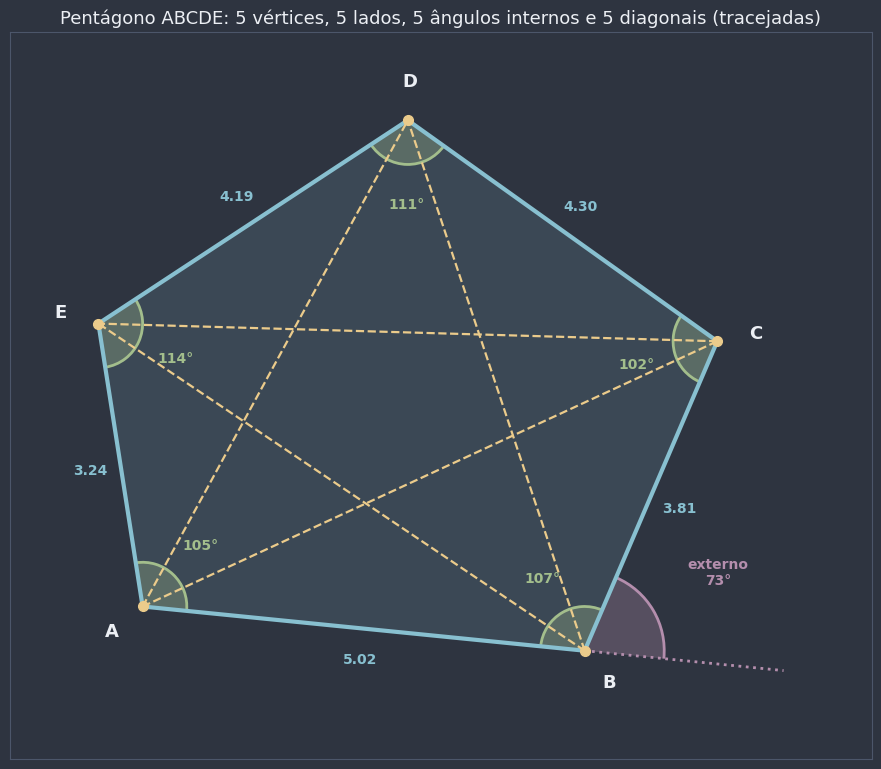

In [5]:
A, B, C, D, E = pentagono
prolongamento = B + 0.45 * (B - A)  # o lado AB "continua" depois de B
fig, ax = plt.subplots(figsize=(9.5, 7.8))
fig.patch.set_facecolor(NORD_FUNDO)
preparar_eixo(ax, pentagono + [prolongamento], margem=1.0)
desenhar_poligono(ax, pentagono, cor=COR_PONTO, largura=3)
for diagonal in diagonais:
    P, Q = pentagono[nomes.index(diagonal[0])], pentagono[nomes.index(diagonal[1])]
    ax.plot(*zip(P, Q), color=COR_AVISO, lw=1.6, linestyle="--")
desenhar_angulos_internos(ax, pentagono, raio=0.5, raio_rotulo=0.95, tamanho_fonte=10)
ax.plot(*zip(B, prolongamento), color=COR_EXTRA, lw=2, linestyle=":")
desenhar_arco(ax, B, prolongamento, C, raio=0.9, cor=COR_EXTRA, rotulo=f"externo\n{180 - internos[1]:.0f}°",
              raio_rotulo=1.75, tamanho_fonte=10)
centro = np.mean(pentagono, axis=0)
for k in range(n):
    rotular_lado(ax, pentagono[k], pentagono[(k + 1) % n], f"{medidas[k]:.2f}", centro, cor=COR_PONTO,
                 distancia=0.35)
rotular_vertices(ax, pentagono, nomes, distancia=0.45)
ax.set_title("Pentágono ABCDE: 5 vértices, 5 lados, 5 ângulos internos e 5 diagonais (tracejadas)",
             color=NORD_TEXTO, fontsize=13)
plt.tight_layout()
plt.show()

### Convexo ou côncavo?

Em 0408a, a distinção entre quadrilátero convexo e côncavo apareceu rapidamente. Agora ela ganha o espaço que merece.

📌 **Definição formal (polígono convexo):** um polígono é **convexo** quando, para **quaisquer** dois pontos da região que ele limita, o segmento que liga esses dois pontos fica **inteiramente contido** nela. Se isso falhar para pelo menos um par de pontos, o polígono é **côncavo**.

Há três maneiras equivalentes de reconhecer um polígono convexo, e cada uma é útil numa situação:

1. **Segmentos:** o segmento entre dois pontos quaisquer do polígono nunca "sai" dele (a definição).
2. **Ângulos:** **todos** os ângulos internos são menores que 180°. Um polígono côncavo tem pelo menos um ângulo interno **maior** que 180°, uma "reentrância", uma ponta afundada.
3. **Retas dos lados:** toda reta que contém um lado deixa o polígono inteiro de **um mesmo lado** dela. No côncavo, alguma dessas retas "corta" a figura.

**No código**, usamos a mesma ideia de 0408a: ande pelo contorno, na ordem dos vértices, e observe para que lado você **vira** em cada vértice. Quem diz isso é o **sinal** da função `orientacao` (positivo: virou à esquerda; negativo: à direita). Num polígono **simples**, virar sempre para o mesmo lado é o mesmo que ter todos os ângulos internos menores que 180°: ele é convexo. Uma única virada "para o lado contrário" denuncia a ponta afundada.

Antes, porém, precisamos garantir que a figura é um polígono simples, isto é, que nenhum par de lados não vizinhos se toca. A função `eh_simples` testa todos esses pares com `segmentos_se_encontram`, uma versão de `segmentos_se_cruzam` (0408a) que também acusa segmentos que apenas **encostam** um no outro.

In [6]:
def segmentos_se_encontram(P1, P2, Q1, Q2) -> bool:
    """True se os segmentos P1P2 e Q1Q2 têm algum ponto em comum: cruzando em "X" ou só encostando
    (uma ponta de um sobre o outro)."""
    def na_caixa(X, P, Q) -> bool:
        return (min(P[0], Q[0]) - 1e-9 <= X[0] <= max(P[0], Q[0]) + 1e-9
                and min(P[1], Q[1]) - 1e-9 <= X[1] <= max(P[1], Q[1]) + 1e-9)

    if segmentos_se_cruzam(P1, P2, Q1, Q2):
        return True
    # Encostar: uma ponta de um segmento é colinear com o outro e fica entre as pontas dele
    casos = ((Q1, P1, P2), (Q2, P1, P2), (P1, Q1, Q2), (P2, Q1, Q2))
    return any(math.isclose(orientacao(P, Q, X), 0, abs_tol=1e-9) and na_caixa(X, P, Q) for X, P, Q in casos)


def eh_simples(vertices) -> bool:
    """True se os vértices, ligados em ordem, formam um polígono simples: três vértices consecutivos
    nunca alinhados e nenhum par de lados não consecutivos se tocando."""
    n = len(vertices)
    if n < 3:
        return False
    if any(math.isclose(orientacao(vertices[k - 1], vertices[k], vertices[(k + 1) % n]), 0, abs_tol=1e-9)
           for k in range(n)):
        return False
    for i, j in combinations(range(n), 2):  # o lado i vai do vértice i ao vértice i + 1
        if sao_consecutivos(i, j, n):
            continue  # lados vizinhos se encontram no vértice comum, e isso é permitido
        if segmentos_se_encontram(vertices[i], vertices[(i + 1) % n], vertices[j], vertices[(j + 1) % n]):
            return False
    return True


def eh_convexo(vertices) -> bool:
    """True se o polígono é simples e, andando pelo contorno, vira sempre para o mesmo lado
    (o sinal de `orientacao` é o mesmo em todos os vértices)."""
    n = len(vertices)
    giros = [orientacao(vertices[k - 1], vertices[k], vertices[(k + 1) % n]) for k in range(n)]
    return eh_simples(vertices) and (all(g > 0 for g in giros) or all(g < 0 for g in giros))


def tipo_de_poligono(vertices) -> str:
    """'convexo', 'côncavo', 'degenerado' (três vértices consecutivos alinhados) ou 'não simples'
    (dois lados não consecutivos se cruzam ou se encostam)."""
    n = len(vertices)
    if any(math.isclose(orientacao(vertices[k - 1], vertices[k], vertices[(k + 1) % n]), 0, abs_tol=1e-9)
           for k in range(n)):
        return "degenerado"
    if not eh_simples(vertices):
        return "não simples"
    return "convexo" if eh_convexo(vertices) else "côncavo"


seta = [np.array(p) for p in [(0.0, 1.0), (3.0, 1.0), (3.0, -0.5), (5.5, 2.0), (3.0, 4.5), (3.0, 3.0), (0.0, 3.0)]]
linhas = []
for nome_figura, vertices in [("pentágono ABCDE", pentagono), ("seta ABCDEFG", seta)]:
    m = len(vertices)
    giros = [orientacao(vertices[k - 1], vertices[k], vertices[(k + 1) % m]) for k in range(m)]
    linhas.append({
        "polígono": nome_figura,
        "vira em cada vértice": "  ".join(f"{LETRAS[k]}: {'esq.' if g > 0 else 'dir.'}" for k, g in enumerate(giros)),
        "ângulos internos": ", ".join(f"{a:.0f}°" for a in angulos_internos(vertices)),
        "eh_convexo": eh_convexo(vertices),
        "tipo": tipo_de_poligono(vertices),
    })
display(pd.DataFrame(linhas).style.hide(axis="index"))

polígono,vira em cada vértice,ângulos internos,eh_convexo,tipo
pentágono ABCDE,A: esq. B: esq. C: esq. D: esq. E: esq.,"105°, 107°, 102°, 111°, 114°",True,convexo
seta ABCDEFG,A: esq. B: dir. C: esq. D: esq. E: esq. F: dir. G: esq.,"90°, 270°, 45°, 90°, 45°, 270°, 90°",False,côncavo


Na seta, os vértices $B$ e $F$ são as pontas afundadas: é ali que o caminho vira para a direita (todos os outros viram para a esquerda), e é ali que os ângulos internos medem 270°. Agora as três caracterizações, desenhadas lado a lado. Os ângulos internos maiores que 180° estão em vermelho; o segmento colorido liga dois pontos **internos**; a reta tracejada contém um lado.

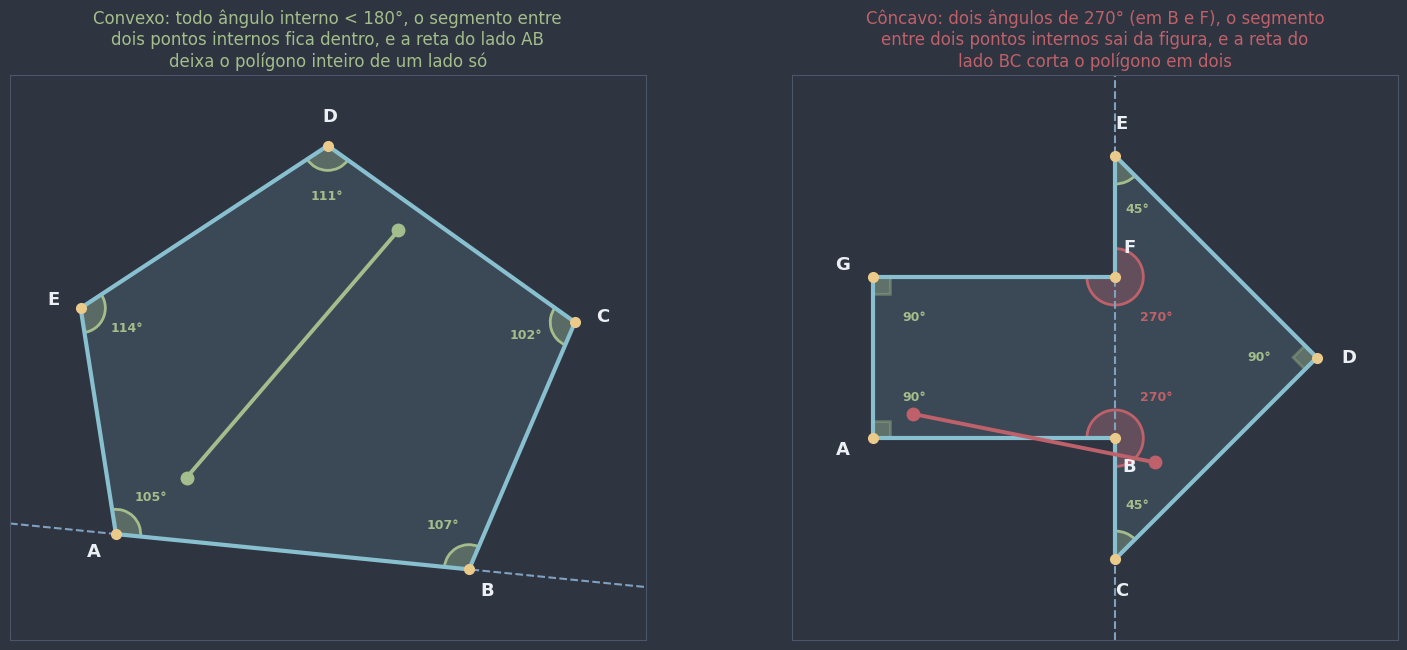

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15.5, 6.6))
fig.patch.set_facecolor(NORD_FUNDO)
figuras = [
    (ax1, pentagono, ((1.0, 0.8), (4.0, 4.3)), (0, 1), COR_DESTAQUE,
     "Convexo: todo ângulo interno < 180°, o segmento entre\ndois pontos internos fica dentro, e a reta do lado AB\ndeixa o polígono inteiro de um lado só"),
    (ax2, seta, ((3.5, 0.7), (0.5, 1.3)), (1, 2), COR_ALERTA,
     "Côncavo: dois ângulos de 270° (em B e F), o segmento\nentre dois pontos internos sai da figura, e a reta do\nlado BC corta o polígono em dois"),
]
for ax, vertices, (P1, P2), (i, j), cor, titulo in figuras:
    preparar_eixo(ax, vertices, margem=1.0)
    ax.axline(tuple(vertices[i]), tuple(vertices[j]), color=COR_SECUNDARIA, lw=1.5, linestyle="--")
    desenhar_poligono(ax, vertices, cor=COR_PONTO, largura=3)
    cores = [COR_ALERTA if a > 180 else COR_DESTAQUE for a in angulos_internos(vertices)]
    desenhar_angulos_internos(ax, vertices, raio=0.35, cores=cores, raio_rotulo=0.72, tamanho_fonte=9)
    ax.plot(*zip(P1, P2), color=cor, lw=2.8, zorder=6)
    for P in (P1, P2):
        ax.plot(*P, "o", color=cor, markersize=9, zorder=7)
    rotular_vertices(ax, vertices, distancia=0.4)
    ax.set_title(titulo, color=cor, fontsize=12)
plt.tight_layout()
plt.show()

⚠️ **Erro comum:** chamar de polígono uma figura que **não** se encaixa na definição. Dois casos aparecem o tempo todo:
- uma linha poligonal **aberta**: falta o último lado, que volta ao primeiro vértice, e a figura não limita região nenhuma;
- uma linha poligonal fechada que **se cruza**, como uma gravata-borboleta: dois lados não vizinhos se encontram fora dos vértices.

Nenhuma das duas é um polígono (simples), e **nenhuma das fórmulas deste notebook vale para elas**. Por isso a ordem das letras no nome do polígono importa: ela diz em que sequência os vértices são ligados (os mesmos pontos, em outra ordem, podem virar uma borboleta, como você viu em 0408a).

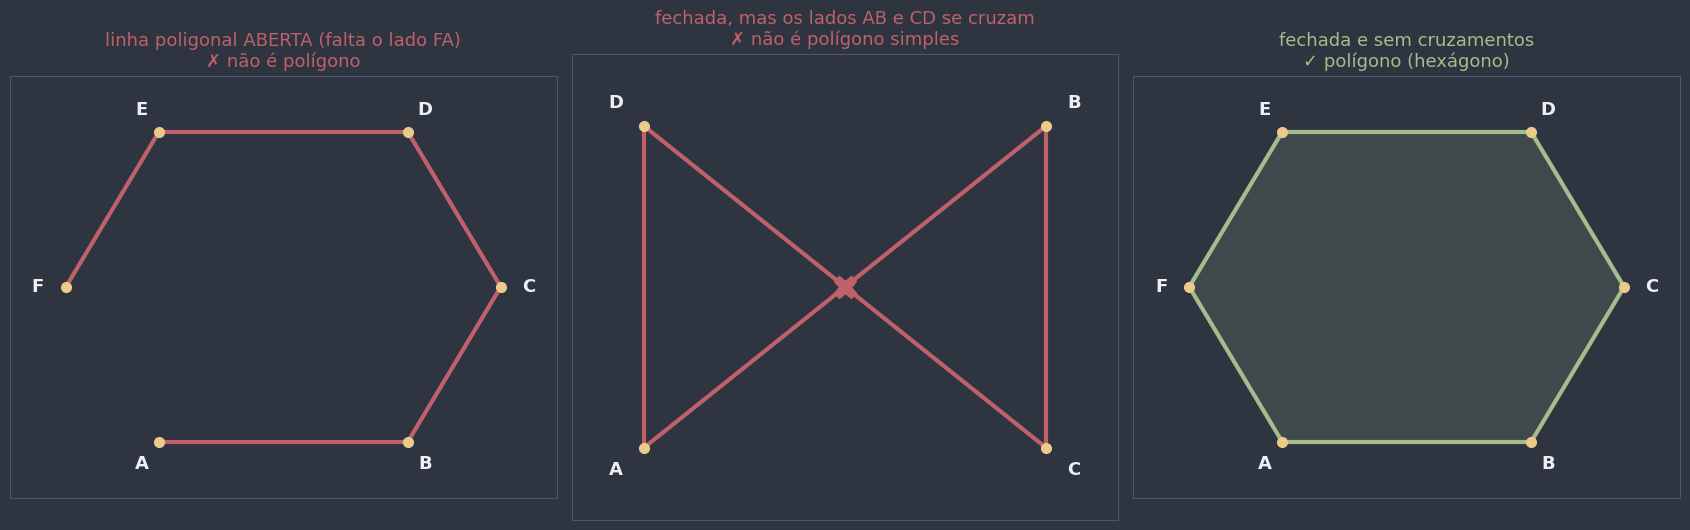

In [8]:
def ponto_de_cruzamento(P1, P2, Q1, Q2) -> np.ndarray:
    """Ponto em que os segmentos P1P2 e Q1Q2 se cruzam (use só quando `segmentos_se_cruzam` der True).
    Por trás, é um sistema linear 2×2 (módulo 03): P1 + t·(P2 − P1) = Q1 + k·(Q2 − Q1)."""
    P1, P2, Q1, Q2 = (np.asarray(p, dtype=float) for p in (P1, P2, Q1, Q2))
    t, _ = np.linalg.solve(np.column_stack([P2 - P1, -(Q2 - Q1)]), Q1 - P1)
    return P1 + t * (P2 - P1)


def marcar_cruzamentos(ax, vertices) -> None:
    """Marca com um X vermelho cada ponto em que dois lados não vizinhos do polígono se cruzam."""
    n = len(vertices)
    for i, j in combinations(range(n), 2):
        if sao_consecutivos(i, j, n):
            continue
        P1, P2, Q1, Q2 = vertices[i], vertices[(i + 1) % n], vertices[j], vertices[(j + 1) % n]
        if segmentos_se_cruzam(P1, P2, Q1, Q2):
            ax.plot(*ponto_de_cruzamento(P1, P2, Q1, Q2), "X", color=COR_ALERTA, markersize=16, zorder=7)


aberta = [np.array(p) for p in [(0.0, 0.0), (4.0, 0.0), (5.5, 2.5), (4.0, 5.0), (0.0, 5.0), (-1.5, 2.5)]]
borboleta = [np.array(p) for p in [(0.0, 0.0), (5.0, 4.0), (5.0, 0.0), (0.0, 4.0)]]
simples = aberta  # os mesmos seis pontos, agora com o lado FA fechando o contorno

fig, eixos = plt.subplots(1, 3, figsize=(17, 5.4))
fig.patch.set_facecolor(NORD_FUNDO)
casos = [
    (eixos[0], aberta, False, COR_ALERTA, "linha poligonal ABERTA (falta o lado FA)\n✗ não é polígono"),
    (eixos[1], borboleta, True, COR_ALERTA, "fechada, mas os lados AB e CD se cruzam\n✗ não é polígono simples"),
    (eixos[2], simples, True, COR_DESTAQUE, "fechada e sem cruzamentos\n✓ polígono (hexágono)"),
]
for ax, vertices, fechado, cor, titulo in casos:
    preparar_eixo(ax, vertices, margem=0.9)
    desenhar_poligono(ax, vertices, cor=cor, largura=3, preencher=(cor == COR_DESTAQUE), fechado=fechado)
    if fechado:
        marcar_cruzamentos(ax, vertices)
    rotular_vertices(ax, vertices, distancia=0.45)
    ax.set_title(titulo, color=cor, fontsize=13)
plt.tight_layout()
plt.show()

🕹️ **Widget interativo:** os sliders `x de D` e `y de D` movem o vértice $D$ de um hexágono; os outros cinco ficam parados. O painel da direita lista os seis ângulos internos (✓ verde quando é menor que 180°) e o tipo do polígono. Tente:
- levar $D$ para **dentro** da figura (por exemplo, $x = 2$ e $y = 2{,}5$): aparece uma ponta afundada e o hexágono fica côncavo;
- levar $D$ para **baixo** do lado $\overline{AB}$ (por exemplo, $x = 2$ e $y = -1$): o lado $\overline{CD}$ cruza $\overline{AB}$, e a figura deixa de ser um polígono simples;
- deixar $D$ **alinhado** com $C$ e $E$ (por exemplo, $x = 3$ e $y = 3{,}75$): o que acontece com o "vértice" $D$?

In [9]:
HEXAGONO_BASE = [np.array(p) for p in [(0.0, 0.0), (4.0, 0.0), (6.0, 2.5), (4.0, 5.0), (0.0, 5.0), (-1.5, 2.5)]]


def explorar_convexidade(x_D: float, y_D: float) -> None:
    vertices = [v.copy() for v in HEXAGONO_BASE]
    vertices[3] = np.array([x_D, y_D])
    tipo = tipo_de_poligono(vertices)
    fig, (ax, ax_lista) = plt.subplots(1, 2, figsize=(14, 6.2), gridspec_kw={"width_ratios": [1.3, 1]})
    fig.patch.set_facecolor(NORD_FUNDO)
    preparar_eixo(ax, [(-2.6, -2.6), (8.2, 7.8)], margem=0)
    if tipo in ("não simples", "degenerado"):
        desenhar_poligono(ax, vertices, cor=COR_ALERTA, largura=3, preencher=False)
        marcar_cruzamentos(ax, vertices)
        if tipo == "degenerado":
            itens = [("três vértices consecutivos estão alinhados:", False),
                     ("o 'vértice' do meio não é um vértice de verdade", False)]
        else:
            itens = [("dois lados não vizinhos se cruzam (ou se encostam):", False),
                     ("não é um polígono simples", False)]
        escrever_checklist(ax_lista, itens, f"Tipo: {tipo}")
        ax.set_title("Isto não é um polígono simples. Mova D de volta.", color=COR_ALERTA, fontsize=13)
    else:
        internos = angulos_internos(vertices)
        cores = [COR_ALERTA if a > 180 else COR_DESTAQUE for a in internos]
        desenhar_poligono(ax, vertices, cor=COR_PONTO, largura=3)
        desenhar_angulos_internos(ax, vertices, raio=0.4, cores=cores, raio_rotulo=0.8, tamanho_fonte=9)
        itens = [(f"ângulo interno em {LETRAS[k]}: {a:.1f}°", a < 180) for k, a in enumerate(internos)]
        itens.append((f"soma dos ângulos internos: {sum(internos):.1f}°", True))
        escrever_checklist(ax_lista, itens, f"Tipo: {tipo}")
        ax.set_title(f"Hexágono {tipo}", color=COR_DESTAQUE if tipo == "convexo" else COR_AVISO, fontsize=13)
    rotular_vertices(ax, vertices, distancia=0.45)
    plt.tight_layout()
    plt.show()


widgets.interact(
    explorar_convexidade,
    x_D=widgets.FloatSlider(value=4.0, min=-2, max=8, step=0.25, description="x de D:"),
    y_D=widgets.FloatSlider(value=5.0, min=-2, max=7.5, step=0.25, description="y de D:"),
);

interactive(children=(FloatSlider(value=4.0, description='x de D:', max=8.0, min=-2.0, step=0.25), FloatSlider…

Repare num detalhe do painel: a **soma** dos ângulos internos do hexágono não mudou quando ele ficou côncavo (desde que continue simples). Guarde essa observação para a seção 4.

🎯 **Aplicação prática — mapas, terrenos e jogos:** as fronteiras de países e estados, os lotes de um loteamento e as áreas de um mapa digital são guardados no computador como polígonos: listas de vértices, em ordem, exatamente como fizemos aqui. Muitos deles são **côncavos** (pense no contorno de um estado brasileiro). Em jogos e simulações, decidir se um polígono é convexo é um passo importante: para polígonos **convexos** existem algoritmos muito mais rápidos de **detecção de colisão** (saber se dois objetos se tocam) e de desenho, por isso os programas costumam quebrar as formas côncavas em pedaços convexos antes de trabalhar com elas.

📖 **Leitura complementar:** [Polígono](https://pt.wikipedia.org/wiki/Pol%C3%ADgono), [Polígono simples](https://pt.wikipedia.org/wiki/Pol%C3%ADgono_simples) e [Polígono convexo](https://pt.wikipedia.org/wiki/Pol%C3%ADgono_convexo)

**Pergunta de checagem:** um polígono com um ângulo interno de 200° pode ser convexo? Por quê?

**Pergunta de checagem:** quantos vértices, lados e ângulos internos tem um polígono de 9 lados? E quantos ângulos externos, contando um por vértice?

## 2. Nomenclatura e classificação

Os polígonos são batizados pelo **número de lados**:

| $n$ | nome | $n$ | nome |
|---|---|---|---|
| 3 | **triângulo** | 8 | **octógono** |
| 4 | **quadrilátero** | 9 | **eneágono** |
| 5 | **pentágono** | 10 | **decágono** |
| 6 | **hexágono** | 11 | **undecágono** |
| 7 | **heptágono** | 12 | **dodecágono** |
| | | 20 | **icoságono** |

Para os demais, diz-se simplesmente **polígono de $n$ lados** (um polígono de 15 lados, de 17 lados...). Existem nomes para vários deles (pentadecágono para 15, por exemplo), mas quase ninguém os usa.

🕵️ **Curiosidade histórica:** os nomes vêm do grego. O final **-gono** vem de *gonía*, "ângulo" (o mesmo radical de *trigonometria*, a "medida do triângulo"), e o prefixo conta: *penta* = 5, *hexa* = 6, *hepta* = 7, *octo* = 8, *ennea* = 9, *deca* = 10, *dodeca* = 12, *icosa* = 20. Os dois primeiros fogem à regra e vêm do latim: **tri**ângulo ("três ângulos") e **quadri**látero ("quatro lados"). Esses prefixos estão por toda parte: o **Pentágono**, sede do Departamento de Defesa dos EUA, tem a forma de um pentágono; os favos das abelhas são **hexágonos**; uma **década** tem 10 anos; e o dado de 20 faces dos jogos de RPG é um **icosa**edro.

Além do número de lados, há uma classificação que olha para os lados e os ângulos:

📌 **Definição formal (equilátero, equiângulo e regular):** um polígono é
- **equilátero** quando todos os seus **lados** são congruentes;
- **equiângulo** quando todos os seus **ângulos internos** são congruentes;
- **regular** quando é **equilátero e equiângulo ao mesmo tempo**.

As propriedades dos polígonos regulares (centro, raio, apótema) ficam para 📌 Polígonos Regulares e Comprimento da Circunferência; aqui vamos só reconhecê-los.

**No código:** um dicionário com os nomes e uma função `nome_poligono(n)` que devolve o nome, ou "polígono de n lados" quando não há nome na tabela.

In [10]:
NOMES_POLIGONOS = {
    3: "triângulo", 4: "quadrilátero", 5: "pentágono", 6: "hexágono", 7: "heptágono", 8: "octógono",
    9: "eneágono", 10: "decágono", 11: "undecágono", 12: "dodecágono", 20: "icoságono",
}


def nome_poligono(n: int) -> str:
    """Nome do polígono de n lados (ou 'polígono de n lados', quando não há nome na tabela).

    Raises:
        ValueError: se n < 3 (não existe polígono com menos de 3 lados).
    """
    if n < 3:
        raise ValueError("um polígono tem pelo menos 3 lados")
    return NOMES_POLIGONOS.get(n, f"polígono de {n} lados")


for n in [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 15, 20]:
    print(f"n = {n:2d}  ->  {nome_poligono(n)}")

n =  3  ->  triângulo
n =  4  ->  quadrilátero
n =  5  ->  pentágono
n =  6  ->  hexágono
n =  7  ->  heptágono
n =  8  ->  octógono
n =  9  ->  eneágono
n = 10  ->  decágono
n = 11  ->  undecágono
n = 12  ->  dodecágono
n = 15  ->  polígono de 15 lados
n = 20  ->  icoságono


A representação gráfica: uma galeria de polígonos **regulares** de 3 a 12 lados. (Para desenhá-los, a função `poligono_regular` espalha os vértices igualmente sobre uma circunferência; a teoria por trás disso fica para depois.)

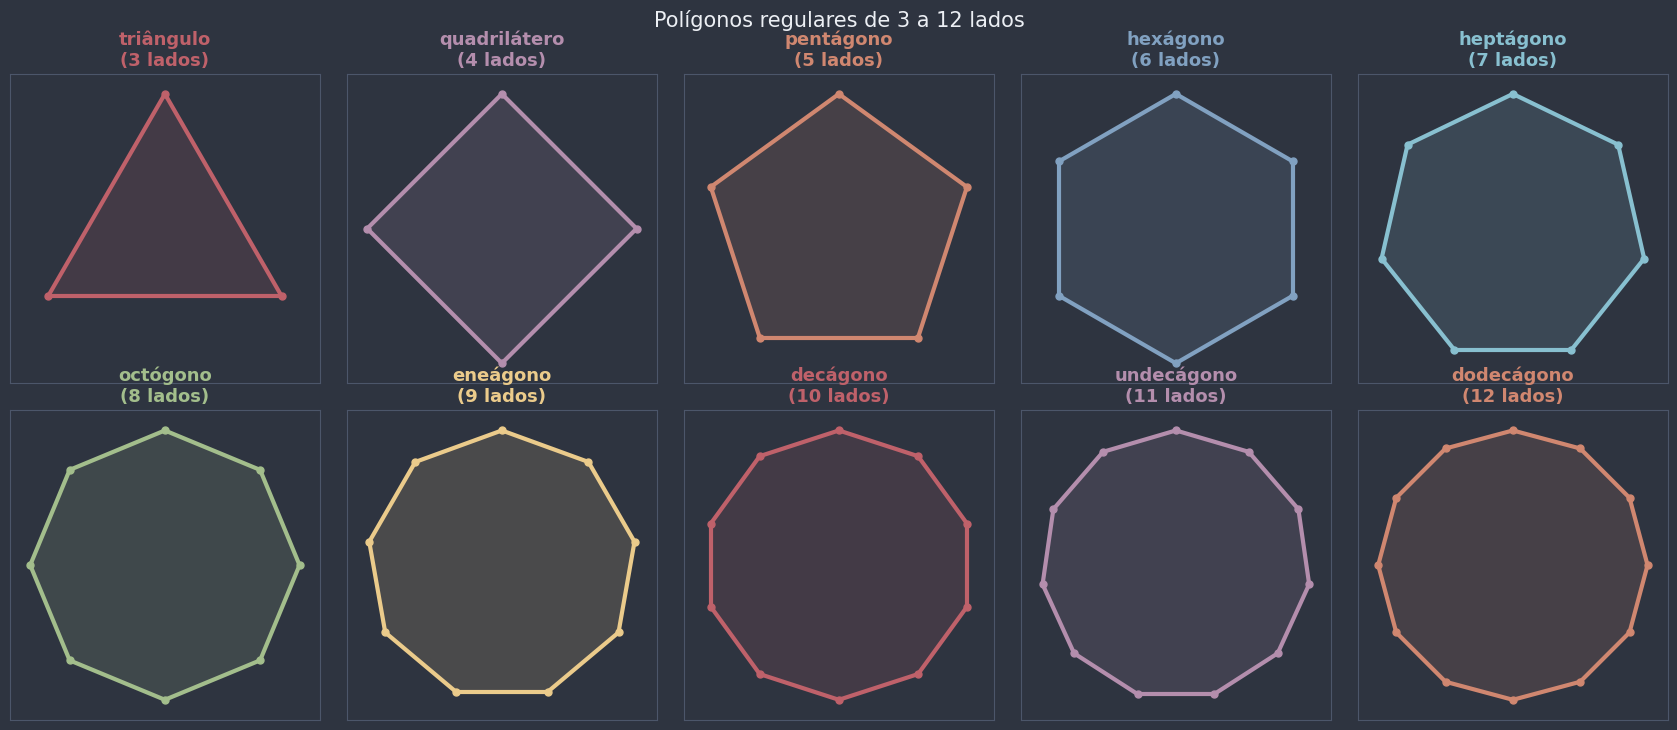

In [11]:
fig, eixos = plt.subplots(2, 5, figsize=(17, 7.4))
fig.patch.set_facecolor(NORD_FUNDO)
for ax, n in zip(eixos.flat, range(3, 13)):
    cor = CORES_CATEGORICAS[n % len(CORES_CATEGORICAS)]
    vertices = poligono_regular(n)
    preparar_eixo(ax, [(-1, -1), (1, 1)], margem=0.15)
    desenhar_poligono(ax, vertices, cor=cor, largura=3)
    for P in vertices:
        ax.plot(*P, "o", color=cor, markersize=5)
    ax.set_title(f"{nome_poligono(n)}\n({n} lados)", color=cor, fontsize=13, fontweight="bold")
fig.suptitle("Polígonos regulares de 3 a 12 lados", color=NORD_TEXTO, fontsize=15)
plt.tight_layout()
plt.show()

⚠️ **Erro comum:** achar que "todos os lados iguais" basta para ser regular. Não basta! Os quadriláteros de [`0409a_paralelogramos_e_casos_particulares.ipynb`](0409a_paralelogramos_e_casos_particulares.ipynb) dão os contraexemplos perfeitos:
- o **losango** é **equilátero** (quatro lados congruentes), mas **não** é equiângulo (dois ângulos agudos e dois obtusos): não é regular;
- o **retângulo** é **equiângulo** (quatro ângulos retos), mas **não** é equilátero (os lados opostos são iguais, mas os vizinhos, em geral, não): não é regular;
- o **quadrado** é os dois ao mesmo tempo: entre os quadriláteros, é o **único** regular.

Vale o mesmo para mais lados: dá para construir, por exemplo, um hexágono com todos os ângulos de 120°, mas com lados alternando entre dois tamanhos.

**No código:** três funções que testam cada propriedade, com uma pequena tolerância (as contas com `float` têm arredondamentos), aplicadas a cinco figuras.

In [12]:
def medidas_dos_lados(vertices) -> list[float]:
    """Medidas dos lados do polígono, na ordem: A1A2, A2A3, ..., AnA1."""
    n = len(vertices)
    return [math.dist(vertices[k], vertices[(k + 1) % n]) for k in range(n)]


def eh_equilatero(vertices) -> bool:
    """True se todos os lados têm a mesma medida."""
    lados = medidas_dos_lados(vertices)
    return all(math.isclose(lado, lados[0], rel_tol=1e-9) for lado in lados)


def eh_equiangulo(vertices) -> bool:
    """True se todos os ângulos internos têm a mesma medida."""
    angulos = angulos_internos(vertices)
    return all(math.isclose(a, angulos[0], rel_tol=1e-9) for a in angulos)


def eh_regular(vertices) -> bool:
    """Regular = equilátero E equiângulo."""
    return eh_equilatero(vertices) and eh_equiangulo(vertices)


def hexagono_equiangulo(lado_1: float, lado_2: float) -> list[np.ndarray]:
    """Hexágono com todos os ângulos de 120°, com lados alternando entre `lado_1` e `lado_2`:
    andando pelo contorno, cada lado gira 60° em relação ao anterior."""
    vertices = [np.array([0.0, 0.0])]
    for k, lado in enumerate([lado_1, lado_2] * 3):
        vertices.append(vertices[-1] + lado * direcao(60 * k))
    return vertices[:-1]  # o último ponto coincide com o primeiro


figuras_classificacao = {
    "losango": [np.array(p) for p in [(0.0, -1.5), (2.4, 0.0), (0.0, 1.5), (-2.4, 0.0)]],
    "retângulo": [np.array(p) for p in [(-2.3, -1.3), (2.3, -1.3), (2.3, 1.3), (-2.3, 1.3)]],
    "quadrado": [np.array(p) for p in [(-1.4, -1.4), (1.4, -1.4), (1.4, 1.4), (-1.4, 1.4)]],
    "hexágono de lados 3 e 1,5": hexagono_equiangulo(3.0, 1.5),
    "pentágono regular": poligono_regular(5, raio=1.8),
}
display(pd.DataFrame([
    {"figura": nome, "lados": ", ".join(f"{m:.2f}" for m in medidas_dos_lados(v)),
     "ângulos internos": ", ".join(f"{a:.0f}°" for a in angulos_internos(v)),
     "equilátero": "✅" if eh_equilatero(v) else "❌", "equiângulo": "✅" if eh_equiangulo(v) else "❌",
     "regular": "✅" if eh_regular(v) else "❌"}
    for nome, v in figuras_classificacao.items()
]).style.hide(axis="index"))

figura,lados,ângulos internos,equilátero,equiângulo,regular
losango,"2.83, 2.83, 2.83, 2.83","116°, 64°, 116°, 64°",✅,❌,❌
retângulo,"4.60, 2.60, 4.60, 2.60","90°, 90°, 90°, 90°",❌,✅,❌
quadrado,"2.80, 2.80, 2.80, 2.80","90°, 90°, 90°, 90°",✅,✅,✅
"hexágono de lados 3 e 1,5","3.00, 1.50, 3.00, 1.50, 3.00, 1.50","120°, 120°, 120°, 120°, 120°, 120°",❌,✅,❌
pentágono regular,"2.12, 2.12, 2.12, 2.12, 2.12","108°, 108°, 108°, 108°, 108°",✅,✅,✅


E o desenho das cinco figuras, com os **tracinhos** de 0402a marcando os lados congruentes (mesmo número de tracinhos = mesma medida):

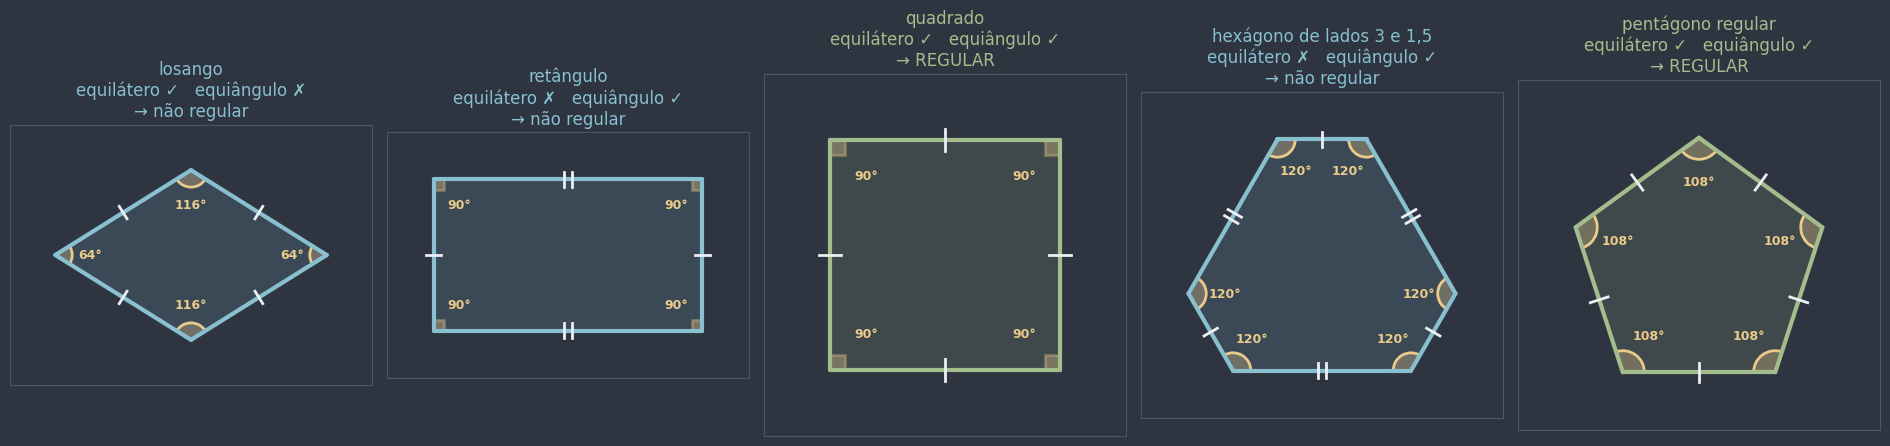

In [13]:
def marca(ok: bool) -> str:
    """✓ quando a propriedade vale, ✗ quando não vale."""
    return "✓" if ok else "✗"


fig, eixos = plt.subplots(1, 5, figsize=(19, 5.4))
fig.patch.set_facecolor(NORD_FUNDO)
for ax, (nome, vertices) in zip(eixos, figuras_classificacao.items()):
    regular = eh_regular(vertices)
    cor = COR_DESTAQUE if regular else COR_PONTO
    preparar_eixo(ax, vertices, margem=0.8)
    desenhar_poligono(ax, vertices, cor=cor, largura=3)
    desenhar_angulos_internos(ax, vertices, raio=0.3, cores=[COR_AVISO] * len(vertices), raio_rotulo=0.62,
                              tamanho_fonte=9)
    medidas_distintas = sorted({round(m, 6) for m in medidas_dos_lados(vertices)})
    for k, medida in enumerate(medidas_dos_lados(vertices)):
        tracos = medidas_distintas.index(round(medida, 6)) + 1
        marcar_congruentes(ax, vertices[k], vertices[(k + 1) % len(vertices)], tracos, tamanho=0.13)
    ax.set_title(f"{nome}\nequilátero {marca(eh_equilatero(vertices))}   equiângulo {marca(eh_equiangulo(vertices))}\n"
                 f"→ {'REGULAR' if regular else 'não regular'}", color=cor, fontsize=12)
plt.tight_layout()
plt.show()

📎 **Conexão:** no triângulo, as duas propriedades andam juntas: todo triângulo **equilátero** é equiângulo (seus ângulos medem 60°) e vice-versa, como você viu em [`0405a_congruencia_de_triangulos.ipynb`](0405a_congruencia_de_triangulos.ipynb). Por isso "triângulo equilátero" e "triângulo regular" são a mesma coisa. A partir de 4 lados, as duas propriedades se separam.

**Pergunta de checagem:** um polígono com todos os lados congruentes é necessariamente regular? Dê um contraexemplo.

**Pergunta de checagem:** qual é o nome de um polígono de 8 lados? E de um de 20 lados? Como você chamaria um polígono de 14 lados?

## 3. Diagonais de um polígono

Voltemos aos apertos de mão. Em um polígono convexo de $n$ lados, quantas diagonais existem? Vamos deduzir a fórmula em dois passos, contando primeiro **por vértice** e depois corrigindo a contagem.

**Passo 1 — de cada vértice, quantas diagonais saem?** Um vértice pode ser ligado aos outros $n - 1$ vértices. Mas, desses, **dois** são seus vizinhos, e a ligação com eles é um **lado**, não uma diagonal. Sobram

$$n - 1 - 2 = n - 3 \text{ diagonais saindo de cada vértice}$$

(ou, dizendo de outro jeito: o vértice não se liga **a si mesmo** nem aos **dois vizinhos**, e $n - 3$ é o que sobra).

**Passo 2 — somando para todos os vértices.** São $n$ vértices, cada um com $n - 3$ diagonais saindo dele: $n \cdot (n - 3)$ "pontas" de diagonal. Mas cada diagonal tem **duas** pontas, e foi contada **duas vezes**: uma a partir de cada extremidade (a diagonal $\overline{AC}$ foi contada saindo de $A$ e saindo de $C$). Dividindo por 2:

📌 **Número de diagonais de um polígono convexo de $n$ lados:**

$$\boxed{d = \frac{n\,(n - 3)}{2}}$$

**Conferindo com os casos conhecidos:**

| polígono | $n$ | $n - 3$ (de cada vértice) | $d = \dfrac{n(n-3)}{2}$ | |
|---|---|---|---|---|
| triângulo | 3 | 0 | $\frac{3 \cdot 0}{2} = 0$ | ✅ todo vértice é vizinho dos outros dois |
| quadrilátero | 4 | 1 | $\frac{4 \cdot 1}{2} = 2$ | ✅ as duas diagonais de 0408a |
| pentágono | 5 | 2 | $\frac{5 \cdot 2}{2} = 5$ | ✅ as cinco da seção 1 |
| hexágono | 6 | 3 | $\frac{6 \cdot 3}{2} = 9$ | ✅ os 9 apertos de mão do gancho |

**No código:** a fórmula vira uma função de uma linha. E, para não ter que acreditar só na dedução, vamos conferir por **força bruta**: gerar os vértices de um polígono, percorrer **todos os pares** de vértices com dois laços (um dentro do outro) e contar os pares **não consecutivos**.

In [14]:
def num_diagonais(n: int) -> int:
    """Número de diagonais de um polígono convexo de n lados: d = n(n − 3)/2."""
    return n * (n - 3) // 2


def diagonais_do_poligono(vertices) -> list[tuple[int, int]]:
    """Lista os pares (i, j) de índices de vértices NÃO consecutivos: as diagonais, por força bruta."""
    n = len(vertices)
    pares = []
    for i in range(n):  # primeiro vértice do par
        for j in range(i + 1, n):  # segundo vértice (j > i, para não contar o mesmo par duas vezes)
            if not sao_consecutivos(i, j, n):
                pares.append((i, j))
    return pares


def contar_diagonais_forca_bruta(vertices) -> int:
    """Conta as diagonais do polígono testando todos os pares de vértices."""
    return len(diagonais_do_poligono(vertices))


linhas = []
for n in range(3, 21):
    contagem = contar_diagonais_forca_bruta(poligono_regular(n))
    linhas.append({
        "n": n, "polígono": nome_poligono(n), "de cada vértice (n − 3)": n - 3, "pontas n·(n − 3)": n * (n - 3),
        "fórmula n(n − 3)/2": num_diagonais(n), "força bruta": contagem,
        "confere?": "✅" if contagem == num_diagonais(n) else "❌",
    })
display(pd.DataFrame(linhas).style.hide(axis="index"))

n,polígono,de cada vértice (n − 3),pontas n·(n − 3),fórmula n(n − 3)/2,força bruta,confere?
3,triângulo,0,0,0,0,✅
4,quadrilátero,1,4,2,2,✅
5,pentágono,2,10,5,5,✅
6,hexágono,3,18,9,9,✅
7,heptágono,4,28,14,14,✅
8,octógono,5,40,20,20,✅
9,eneágono,6,54,27,27,✅
10,decágono,7,70,35,35,✅
11,undecágono,8,88,44,44,✅
12,dodecágono,9,108,54,54,✅


A dedução, em desenho, no hexágono: à esquerda, as $n - 3 = 3$ diagonais que saem de $A$; no meio, cada diagonal pintada **metade de uma cor, metade de outra**, conforme o vértice de onde ela "sai" (são $6 \times 3 = 18$ meias-diagonais, as "pontas"); à direita, juntando as metades, $18 \div 2 = 9$ diagonais.

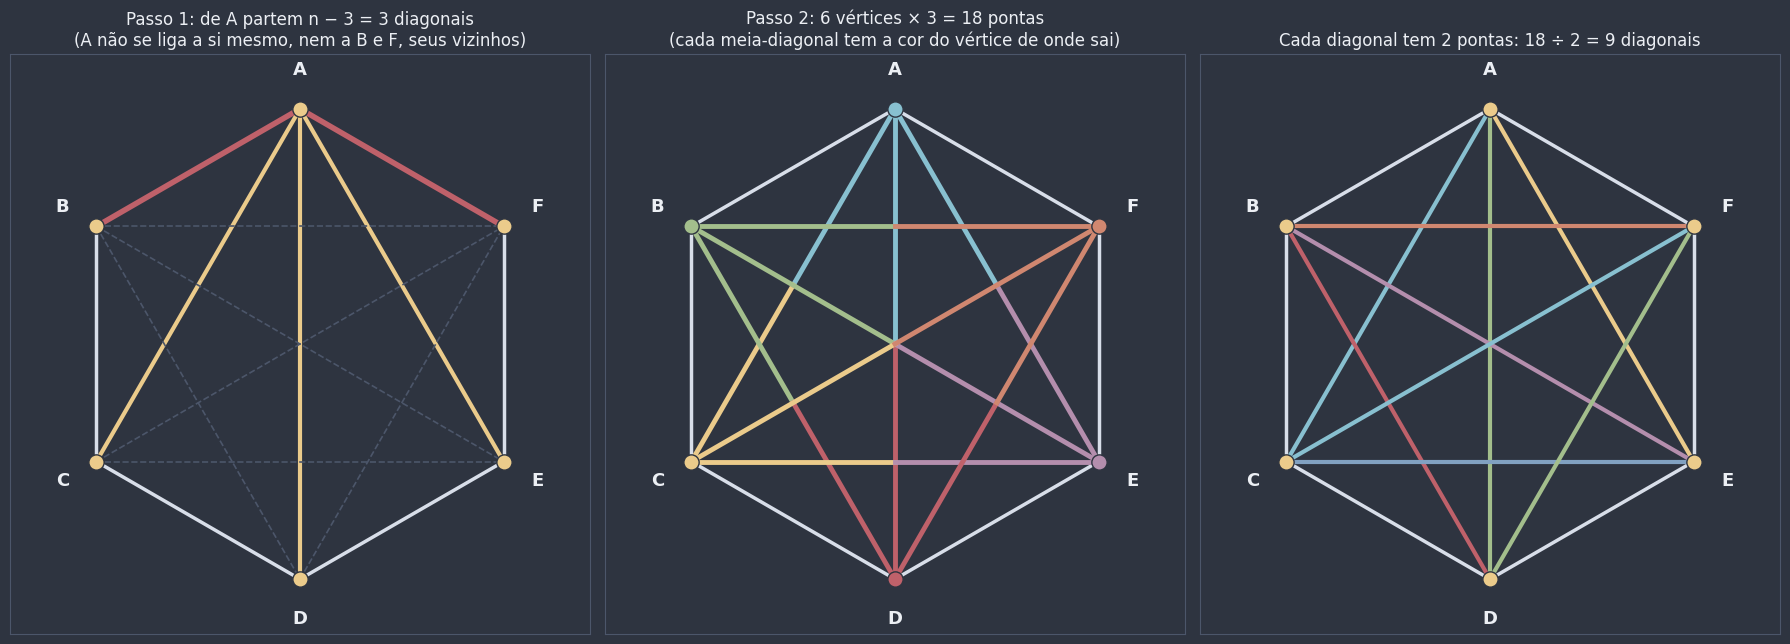

In [15]:
hexagono = poligono_regular(6, raio=3)
pares = diagonais_do_poligono(hexagono)
fig, eixos = plt.subplots(1, 3, figsize=(18, 6.4))
fig.patch.set_facecolor(NORD_FUNDO)
titulos = [
    "Passo 1: de A partem n − 3 = 3 diagonais\n(A não se liga a si mesmo, nem a B e F, seus vizinhos)",
    "Passo 2: 6 vértices × 3 = 18 pontas\n(cada meia-diagonal tem a cor do vértice de onde sai)",
    "Cada diagonal tem 2 pontas: 18 ÷ 2 = 9 diagonais",
]
for painel, (ax, titulo) in enumerate(zip(eixos, titulos)):
    preparar_eixo(ax, [(-3, -3), (3, 3)], margem=0.7)
    desenhar_poligono(ax, hexagono, cor=NORD_TEXTO_SEC, largura=2.5, preencher=False)
    for k, (i, j) in enumerate(pares):
        P, Q, M = hexagono[i], hexagono[j], ponto_medio(hexagono[i], hexagono[j])
        if painel == 0:
            if 0 in (i, j):
                ax.plot(*zip(P, Q), color=COR_AVISO, lw=3)
            else:
                ax.plot(*zip(P, Q), color=NORD_LINHA, lw=1.2, linestyle="--")
        elif painel == 1:
            ax.plot(*zip(P, M), color=CORES_CATEGORICAS[i % 7], lw=3.5)
            ax.plot(*zip(M, Q), color=CORES_CATEGORICAS[j % 7], lw=3.5)
        else:
            ax.plot(*zip(P, Q), color=CORES_CATEGORICAS[k % 7], lw=3)
    if painel == 0:
        for viz in (1, 5):
            ax.plot(*zip(hexagono[0], hexagono[viz]), color=COR_ALERTA, lw=4)
    for k, P in enumerate(hexagono):
        cor_vertice = CORES_CATEGORICAS[k % 7] if painel == 1 else COR_AVISO
        ax.plot(*P, "o", color=cor_vertice, markersize=11, zorder=6, markeredgecolor=NORD_FUNDO)
    rotular_vertices(ax, hexagono, distancia=0.5, cor=COR_AVISO)
    ax.set_title(titulo, color=NORD_TEXTO, fontsize=12)
plt.tight_layout()
plt.show()

🕹️ **Widget interativo:** o slider `n` escolhe o número de lados (de 3 a 20). O polígono é desenhado com **todas** as diagonais, e o painel mostra a dedução passo a passo, comparando a fórmula com a contagem feita pelo programa. Marque `destacar as de A` para ver só as $n - 3$ diagonais que saem do vértice $A$. Com quantos lados o desenho fica parecido com o "novelo" de 20 pessoas do gancho?

In [16]:
def explorar_diagonais(n: int, destacar_A: bool) -> None:
    vertices = poligono_regular(n, raio=3)
    pares = diagonais_do_poligono(vertices)
    fig, (ax, ax_lista) = plt.subplots(1, 2, figsize=(14, 6.4), gridspec_kw={"width_ratios": [1.2, 1]})
    fig.patch.set_facecolor(NORD_FUNDO)
    preparar_eixo(ax, [(-3.7, -3.7), (3.7, 3.7)], margem=0)
    desenhar_poligono(ax, vertices, cor=COR_PONTO, largura=2.5)
    for i, j in pares:
        if destacar_A and i == 0:
            ax.plot(*zip(vertices[i], vertices[j]), color=COR_AVISO, lw=2.5, zorder=4)
        else:
            ax.plot(*zip(vertices[i], vertices[j]), color=COR_SECUNDARIA, lw=1, alpha=0.25 if destacar_A else 0.6)
    rotular_vertices(ax, vertices, distancia=0.4, tamanho=13 if n <= 12 else 9)
    itens = [
        (f"de cada vértice partem n − 3 = {n} − 3 = {n - 3} diagonais", True),
        (f"pontas: n · (n − 3) = {n} · {n - 3} = {n * (n - 3)}", True),
        (f"cada diagonal tem 2 pontas: {n * (n - 3)} ÷ 2 = {num_diagonais(n)}", True),
        (f"diagonais contadas pelo programa: {len(pares)}", True),
        ("fórmula e contagem coincidem", len(pares) == num_diagonais(n)),
    ]
    escrever_checklist(ax_lista, itens, f"{nome_poligono(n)}: d = n(n − 3)/2 = {num_diagonais(n)}")
    ax.set_title(f"{nome_poligono(n)} ({n} lados) com as suas {len(pares)} diagonais", color=NORD_TEXTO, fontsize=13)
    plt.tight_layout()
    plt.show()


widgets.interact(
    explorar_diagonais,
    n=widgets.IntSlider(value=6, min=3, max=20, step=1, description="n:"),
    destacar_A=widgets.Checkbox(value=False, description="destacar as de A"),
);

interactive(children=(IntSlider(value=6, description='n:', max=20, min=3), Checkbox(value=False, description='…

💡 **Dica — o aperto de mão, resolvido:** na mesa de 6 pessoas, $d = \frac{6 \cdot 3}{2} = 9$ apertos de mão; com 20 pessoas, $d = \frac{20 \cdot 17}{2} = 170$. Sem contar nenhuma linha.

A última representação: o **gráfico** de $d$ em função de $n$. Repare que o número de diagonais cresce **cada vez mais rápido**: ele é aproximadamente $\frac{n^2}{2}$, uma função do 2º grau (o termo $n^2$ domina quando $n$ é grande). Dobrar o número de lados **quase quadruplica** o número de diagonais.

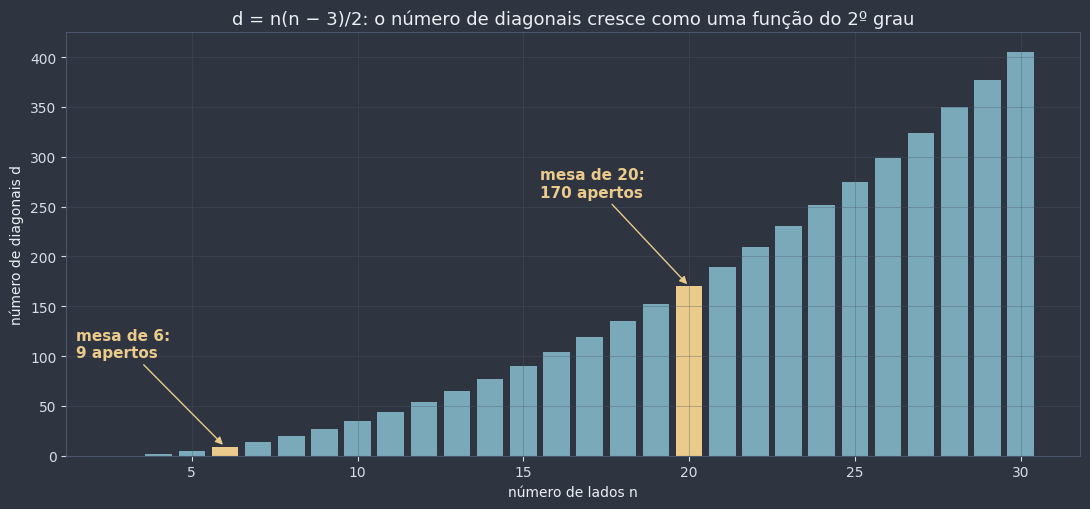

In [17]:
valores_n = np.arange(3, 31)
fig, ax = plt.subplots(figsize=(11, 5.2))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)
ax.bar(valores_n, [num_diagonais(n) for n in valores_n], color=COR_PONTO, alpha=0.85)
for n, texto in [(6, "mesa de 6:\n9 apertos"), (20, "mesa de 20:\n170 apertos")]:
    ax.bar(n, num_diagonais(n), color=COR_AVISO)
    ax.annotate(texto, xy=(n, num_diagonais(n)), xytext=(n - 4.5, num_diagonais(n) + 90), color=COR_AVISO,
                fontsize=11, fontweight="bold", arrowprops={"arrowstyle": "-|>", "color": COR_AVISO})
ax.set_xlabel("número de lados n", color=NORD_TEXTO)
ax.set_ylabel("número de diagonais d", color=NORD_TEXTO)
ax.set_title("d = n(n − 3)/2: o número de diagonais cresce como uma função do 2º grau", color=NORD_TEXTO,
             fontsize=13)
plt.tight_layout()
plt.show()

🎯 **Aplicação prática — redes e conexões:** quantos cabos são necessários para ligar **diretamente** cada um de $n$ computadores a todos os outros? Quantos voos diretos são possíveis entre $n$ cidades? É a mesma contagem: ligar **todos os pares** de pontos. Num polígono, os pares de vértices se dividem em dois grupos: os vizinhos (os $n$ **lados**) e os não vizinhos (as **diagonais**). Então

$$\underbrace{\text{todos os pares}}_{\text{ligações possíveis}} = \underbrace{n}_{\text{lados}} + \underbrace{\frac{n(n-3)}{2}}_{\text{diagonais}} = \frac{n(n - 1)}{2}.$$

Por isso redes "todos com todos" ficam caras muito depressa, e na prática se usam **centrais** (roteadores, aeroportos que funcionam como *hubs*) que diminuem o número de ligações.

📎 **Conexão:** o número de pares que se pode formar com $n$ objetos tem nome e símbolo próprios em **Análise Combinatória** (módulo 08): são as **combinações de $n$ elementos tomados 2 a 2**, $C(n, 2) = \frac{n(n-1)}{2}$, que o Python calcula com `math.comb(n, 2)`. Em essência, a fórmula das diagonais é $d = C(n, 2) - n$: todos os pares, menos os lados.

In [18]:
display(pd.DataFrame([
    {"n": n, "todos os pares C(n, 2)": math.comb(n, 2), "lados": n, "C(n, 2) − n": math.comb(n, 2) - n,
     "n(n − 3)/2": num_diagonais(n), "confere?": "✅" if math.comb(n, 2) - n == num_diagonais(n) else "❌"}
    for n in [3, 4, 5, 6, 8, 10, 12, 20, 50, 100]
]).style.hide(axis="index"))

n,"todos os pares C(n, 2)",lados,"C(n, 2) − n",n(n − 3)/2,confere?
3,3,3,0,0,✅
4,6,4,2,2,✅
5,10,5,5,5,✅
6,15,6,9,9,✅
8,28,8,20,20,✅
10,45,10,35,35,✅
12,66,12,54,54,✅
20,190,20,170,170,✅
50,1225,50,1175,1175,✅
100,4950,100,4850,4850,✅


**Pergunta de checagem:** quantas diagonais tem um polígono de 12 lados?

**Pergunta de checagem:** existe um polígono com exatamente 20 diagonais? Qual? E com exatamente 10 diagonais? (Dica: teste alguns valores de $n$ na fórmula, ou olhe a tabela.)

## 4. Soma dos ângulos internos

Em 0408a, uma diagonal dividiu o quadrilátero em **dois** triângulos, e a soma dos seus ângulos internos saiu de graça: $2 \cdot 180^\circ = 360^\circ$. A mesma técnica funciona para qualquer número de lados: basta usar **todas as diagonais que saem de um mesmo vértice**.

**A dedução.** Num polígono convexo de $n$ lados, escolha um vértice, digamos $A_1$, e trace todas as diagonais que partem dele.

| Passo | Afirmação | Justificativa |
|---|---|---|
| 1 | de $A_1$ partem $n - 3$ diagonais | seção 3 |
| 2 | elas dividem o polígono em $n - 2$ triângulos | cada diagonal "corta" uma peça em duas: começando com 1 peça (o polígono) e fazendo $n - 3$ cortes, ficamos com $1 + (n - 3) = n - 2$ peças |
| 3 | os ângulos desses triângulos **preenchem exatamente** os ângulos internos do polígono | em $A_1$, os ângulos dos triângulos são vizinhos (adjacentes) e somam $\hat{A}_1$; cada outro vértice é canto de um triângulo só, ou de dois triângulos vizinhos que somam o ângulo daquele vértice |
| 4 | cada triângulo contribui com $180^\circ$ | soma dos ângulos internos do triângulo (0404a, demonstrada em 0406a) |
| 5 | $S_i = (n - 2) \cdot 180^\circ$ | passos 2, 3 e 4 ∎ |

📌 **Soma dos ângulos internos de um polígono convexo de $n$ lados:**

$$\boxed{S_i = (n - 2) \cdot 180^\circ}$$

**Conferindo:** triângulo ($n = 3$): $1 \cdot 180^\circ = 180^\circ$ ✅; quadrilátero ($n = 4$): $2 \cdot 180^\circ = 360^\circ$ ✅ (0408a); pentágono ($n = 5$): $3 \cdot 180^\circ = 540^\circ$; hexágono ($n = 6$): $4 \cdot 180^\circ = 720^\circ$.

**A representação numérica.** A fórmula para vários valores de $n$ e, depois, um teste de verdade: sortear um heptágono convexo **qualquer** (sem nenhum ângulo especial), medir cada ângulo interno com o transferidor digital e somar.

In [19]:
def soma_angulos_internos(n: int) -> int:
    """Soma dos ângulos internos (em graus) de um polígono convexo de n lados: (n − 2)·180°."""
    return (n - 2) * 180


display(pd.DataFrame([
    {"n": n, "polígono": nome_poligono(n), "diagonais de A (n − 3)": n - 3, "triângulos (n − 2)": n - 2,
     "S_i = (n − 2)·180°": f"{soma_angulos_internos(n)}°"}
    for n in range(3, 13)
]).style.hide(axis="index"))

heptagono = poligono_convexo_aleatorio(7, np.random.default_rng(7))
internos = angulos_internos(heptagono)
print(f"Heptágono sorteado ({tipo_de_poligono(heptagono)}):")
for k, a in enumerate(internos):
    print(f"  ângulo em {LETRAS[k]}: {a:8.4f}°")
print(f"  soma medida: {sum(internos):.4f}°   fórmula (7 − 2)·180° = {soma_angulos_internos(7)}°")

n,polígono,diagonais de A (n − 3),triângulos (n − 2),S_i = (n − 2)·180°
3,triângulo,0,1,180°
4,quadrilátero,1,2,360°
5,pentágono,2,3,540°
6,hexágono,3,4,720°
7,heptágono,4,5,900°
8,octógono,5,6,1080°
9,eneágono,6,7,1260°
10,decágono,7,8,1440°
11,undecágono,8,9,1620°
12,dodecágono,9,10,1800°


Heptágono sorteado (convexo):
  ângulo em A: 104.4019°
  ângulo em B: 122.3735°
  ângulo em C: 138.4590°
  ângulo em D: 131.4456°
  ângulo em E: 118.2956°
  ângulo em F: 142.3119°
  ângulo em G: 142.7126°
  soma medida: 900.0000°   fórmula (7 − 2)·180° = 900°


A representação gráfica da demonstração, num hexágono convexo irregular: as $n - 3 = 3$ diagonais que saem de $A$, os $n - 2 = 4$ triângulos, cada um com uma cor, e cada pedaço de ângulo pintado com a cor do triângulo a que pertence. Repare como, em $A$, os quatro pedaços se juntam para formar o ângulo $\hat{A}$ inteiro.

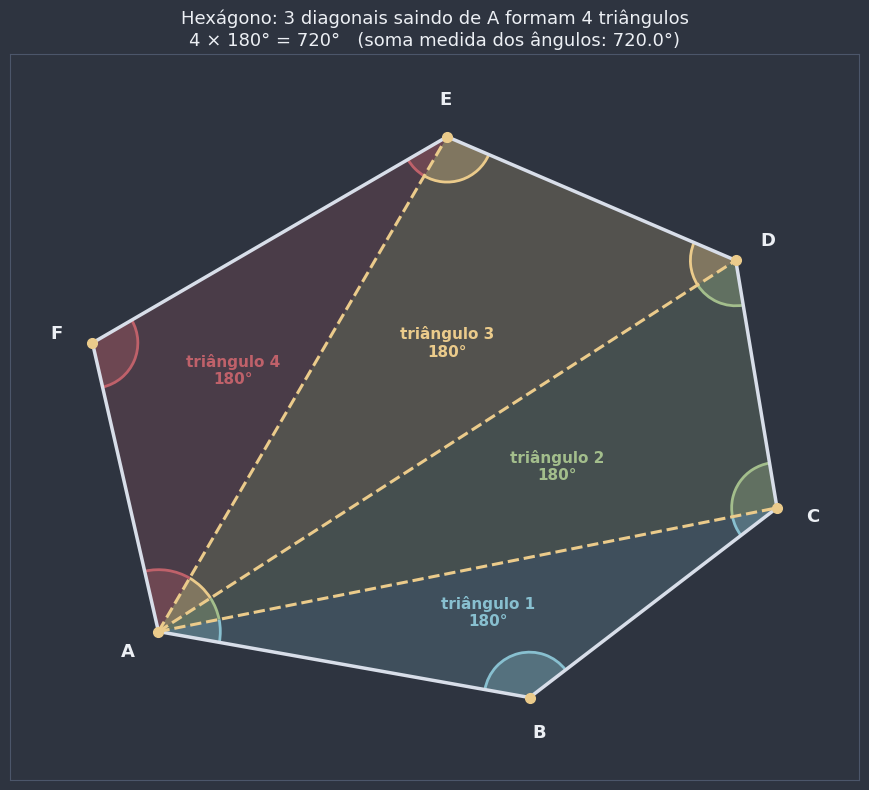

In [20]:
def triangulacao_a_partir_de(vertices, k: int = 0) -> list[list[np.ndarray]]:
    """Os n − 2 triângulos formados pelas diagonais que saem do vértice de índice k."""
    n = len(vertices)
    V = vertices[k]
    return [[V, vertices[(k + m) % n], vertices[(k + m + 1) % n]] for m in range(1, n - 1)]


hexagono_irregular = [np.array(p) for p in [(0.0, 0.0), (4.5, -0.8), (7.5, 1.5), (7.0, 4.5), (3.5, 6.0), (-0.8, 3.5)]]
triangulos = triangulacao_a_partir_de(hexagono_irregular, 0)
fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor(NORD_FUNDO)
preparar_eixo(ax, hexagono_irregular, margem=1.0)
for t, (P, Q, R) in enumerate(triangulos):
    cor = CORES_CATEGORICAS[t]
    ax.add_patch(Polygon([P, Q, R], closed=True, facecolor=cor, alpha=0.2, edgecolor="none"))
    for vertice, p, q in ((P, Q, R), (Q, R, P), (R, P, Q)):
        desenhar_arco(ax, vertice, p, q, raio=0.75 if vertice is P else 0.55, cor=cor, marcar_reto=False)
    centro_t = (P + Q + R) / 3
    ax.text(*centro_t, f"triângulo {t + 1}\n180°", color=cor, fontsize=11, fontweight="bold", ha="center", va="center")
desenhar_poligono(ax, hexagono_irregular, cor=NORD_TEXTO_SEC, largura=2.5, preencher=False)
for m in range(2, 5):
    ax.plot(*zip(hexagono_irregular[0], hexagono_irregular[m]), color=COR_AVISO, lw=2.2, linestyle="--")
rotular_vertices(ax, hexagono_irregular, distancia=0.45)
soma = sum(angulos_internos(hexagono_irregular))
ax.set_title(f"Hexágono: 3 diagonais saindo de A formam 4 triângulos\n"
             f"4 × 180° = 720°   (soma medida dos ângulos: {soma:.1f}°)", color=NORD_TEXTO, fontsize=13)
plt.tight_layout()
plt.show()

🕹️ **Widget interativo:** o slider `n` escolhe o número de lados, o slider `forma` sorteia um polígono convexo diferente (com o mesmo número de lados) e o slider `partida` escolhe o vértice de onde saem as diagonais. O painel mostra a contagem de triângulos e compara $(n - 2) \cdot 180^\circ$ com a soma **medida** dos ângulos. Experimente mudar a forma e o vértice de partida: a triangulação muda, mas a soma muda?

In [ ]:
def explorar_triangulacao(n: int, forma: int, partida: int) -> None:
    vertices = poligono_convexo_aleatorio(n, np.random.default_rng(forma))
    k = partida % n
    fig, (ax, ax_lista) = plt.subplots(1, 2, figsize=(14, 6.2), gridspec_kw={"width_ratios": [1.25, 1]})
    fig.patch.set_facecolor(NORD_FUNDO)
    preparar_eixo(ax, [(-3.3, -2.6), (3.3, 2.6)], margem=0.3)
    for t, triangulo in enumerate(triangulacao_a_partir_de(vertices, k)):
        ax.add_patch(Polygon(triangulo, closed=True, facecolor=CORES_CATEGORICAS[t % 7], alpha=0.35,
                             edgecolor=NORD_FUNDO, lw=1))
    desenhar_poligono(ax, vertices, cor=NORD_TEXTO_SEC, largura=2.5, preencher=False)
    for m in range(2, n - 1):
        ax.plot(*zip(vertices[k], vertices[(k + m) % n]), color=COR_AVISO, lw=2, linestyle="--")
    rotular_vertices(ax, vertices, distancia=0.3, tamanho=12)
    ax.plot(*vertices[k], "o", color=COR_ALERTA, markersize=12, zorder=6)
    soma = sum(angulos_internos(vertices))
    itens = [
        (f"diagonais saindo de {LETRAS[k]}: n − 3 = {n - 3}", True),
        (f"triângulos formados: n − 2 = {n - 2}", True),
        (f"(n − 2) · 180° = {n - 2} · 180° = {soma_angulos_internos(n)}°", True),
        (f"soma medida dos {n} ângulos internos: {soma:.2f}°", True),
        ("fórmula e medida coincidem", math.isclose(soma, soma_angulos_internos(n), abs_tol=1e-6)),
    ]
    escrever_checklist(ax_lista, itens, f"{nome_poligono(n)} convexo")
    ax.set_title(f"Triangulação a partir de {LETRAS[k]}: {n - 2} triângulo{'s' if n > 3 else ''}", color=NORD_TEXTO,
                 fontsize=13)
    plt.tight_layout()
    plt.show()


widgets.interact(
    explorar_triangulacao,
    n=widgets.IntSlider(value=7, min=3, max=12, step=1, description="n:"),
    forma=widgets.IntSlider(value=1, min=0, max=30, step=1, description="forma:"),
    partida=widgets.IntSlider(value=0, min=0, max=11, step=1, description="partida:"),
);

interactive(children=(IntSlider(value=7, description='n:', max=12, min=3), IntSlider(value=1, description='for…

💡 **Dica — polígono regular:** num polígono regular, os $n$ ângulos internos são congruentes, então cada um mede a soma dividida por $n$:

$$a_i = \frac{(n - 2) \cdot 180^\circ}{n}.$$

Hexágono regular: $\frac{4 \cdot 180^\circ}{6} = 120^\circ$; octógono regular: $\frac{6 \cdot 180^\circ}{8} = 135^\circ$; dodecágono regular: $\frac{10 \cdot 180^\circ}{12} = 150^\circ$. (O desenvolvimento das propriedades dos regulares fica para 📌 Polígonos Regulares e Comprimento da Circunferência.)

🎯 **Aplicação prática — computação gráfica:** toda forma que aparece num jogo ou num filme de animação é desenhada pela placa de vídeo como um monte de **triângulos** (as "malhas de triângulos" que você conheceu em 0404a). Quando um programa precisa desenhar um polígono de $n$ lados, a primeira coisa que ele faz é **triangulá-lo**, e, num polígono convexo, o jeito mais simples é exatamente o desta seção: o "leque" de diagonais saindo de um vértice, que gera $n - 2$ triângulos. A fórmula diz quantos triângulos a placa de vídeo vai processar.

⚠️ **Erro comum:** achar que a fórmula só vale para polígonos convexos, ou, no outro extremo, aplicar a técnica do "leque" sem cuidado num polígono côncavo. A **fórmula** $(n - 2) \cdot 180^\circ$ continua valendo para qualquer polígono simples, mesmo côncavo (o ângulo da ponta afundada entra com sua medida maior que 180°): todo polígono simples pode ser dividido em $n - 2$ triângulos. O que pode falhar é a **técnica**: a partir de um vértice qualquer, algumas diagonais podem sair da figura. Veja na seta da seção 1:

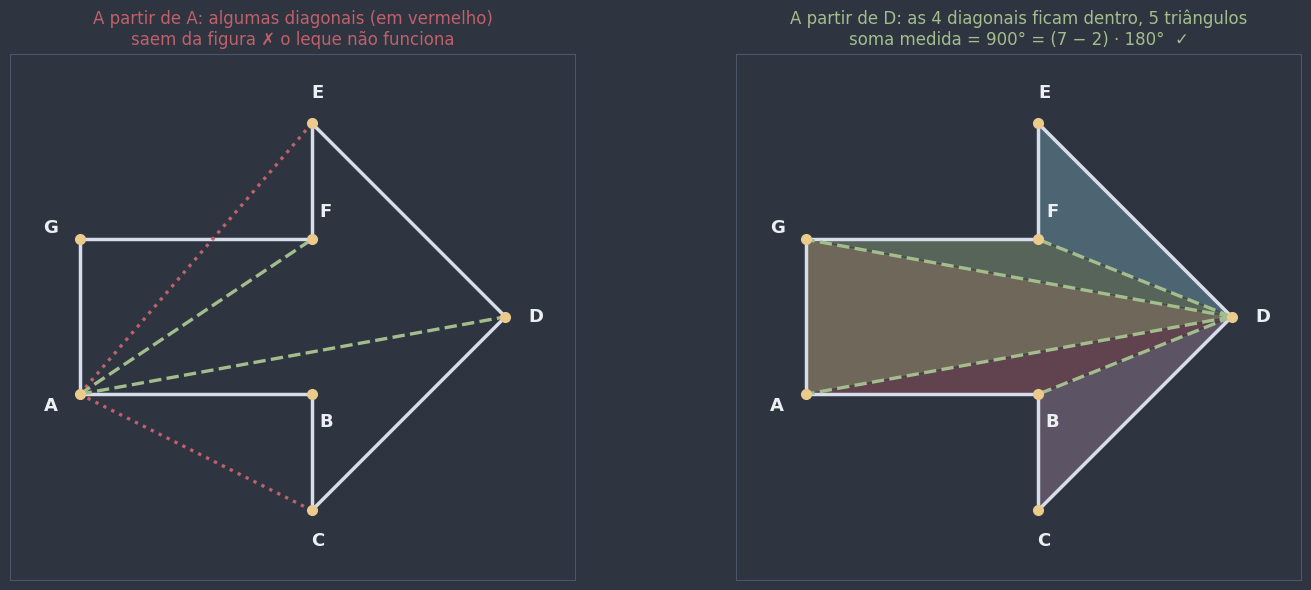

In [22]:
def diagonal_interna(vertices, i: int, j: int) -> bool:
    """True se a diagonal que liga os vértices i e j fica dentro do polígono: não toca nenhum lado
    (fora as pontas) e o seu ponto médio está no interior."""
    n = len(vertices)
    P, Q = vertices[i], vertices[j]
    for k in range(n):
        if k in (i, j) or (k + 1) % n in (i, j):
            continue  # lados que têm i ou j como ponta: encostam na diagonal só ali
        if segmentos_se_encontram(P, Q, vertices[k], vertices[(k + 1) % n]):
            return False
    return Path(np.array(vertices)).contains_point(ponto_medio(P, Q))


n_seta = len(seta)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor(NORD_FUNDO)
for ax, k in ((ax1, 0), (ax2, 3)):
    preparar_eixo(ax, seta, margem=0.9)
    todas_dentro = all(diagonal_interna(seta, k, (k + m) % n_seta) for m in range(2, n_seta - 1))
    if todas_dentro:
        for t, triangulo in enumerate(triangulacao_a_partir_de(seta, k)):
            ax.add_patch(Polygon(triangulo, closed=True, facecolor=CORES_CATEGORICAS[t % 7], alpha=0.35,
                                 edgecolor=NORD_FUNDO, lw=1))
    desenhar_poligono(ax, seta, cor=NORD_TEXTO_SEC, largura=2.5, preencher=False)
    for m in range(2, n_seta - 1):
        j = (k + m) % n_seta
        dentro = diagonal_interna(seta, k, j)
        ax.plot(*zip(seta[k], seta[j]), color=COR_DESTAQUE if dentro else COR_ALERTA, lw=2.4,
                linestyle="--" if dentro else ":")
    rotular_vertices(ax, seta, distancia=0.4)
    if todas_dentro:
        titulo = (f"A partir de {LETRAS[k]}: as 4 diagonais ficam dentro, {n_seta - 2} triângulos\n"
                  f"soma medida = {sum(angulos_internos(seta)):.0f}° = (7 − 2) · 180°  ✓")
    else:
        titulo = f"A partir de {LETRAS[k]}: algumas diagonais (em vermelho)\nsaem da figura ✗ o leque não funciona"
    ax.set_title(titulo, color=COR_DESTAQUE if todas_dentro else COR_ALERTA, fontsize=12)
plt.tight_layout()
plt.show()

Na seta, o leque a partir de $A$ falha, mas a partir de $D$ (a ponta da flecha) funciona: são $7 - 2 = 5$ triângulos, e os ângulos internos da seta, $90^\circ, 270^\circ, 45^\circ, 90^\circ, 45^\circ, 270^\circ$ e $90^\circ$, somam $900^\circ = 5 \cdot 180^\circ$, como a fórmula prevê. Neste curso, porém, vamos **manter o foco nos convexos**, em que qualquer vértice serve de partida.

📖 **Leitura complementar:** [Triangulação (geometria)](https://pt.wikipedia.org/wiki/Triangula%C3%A7%C3%A3o_(geometria))

**Pergunta de checagem:** qual polígono convexo tem a soma dos ângulos internos igual a 1440°?

**Pergunta de checagem:** existe polígono convexo cuja soma dos ângulos internos seja 1000°? Por quê?

## 5. Soma dos ângulos externos

Agora o último ângulo da tabela do gancho. Em cada vértice de um polígono convexo, tomamos **um** ângulo externo: o ângulo entre um lado e o prolongamento do lado anterior (como o ângulo lilás em $B$, na seção 1). Quanto dá a soma desses $n$ ângulos externos?

**A dedução (a mais elegante do notebook).** Em cada vértice, o ângulo interno e o ângulo externo são **suplementares** (juntos formam um ângulo raso, 0403a):

$$\hat{\imath} + \hat{e} = 180^\circ \quad \text{em cada vértice}.$$

Somando essa igualdade nos $n$ vértices:

$$S_i + S_e = n \cdot 180^\circ.$$

E já sabemos $S_i$ (seção 4). Então

$$S_e = n \cdot 180^\circ - (n - 2) \cdot 180^\circ = n \cdot 180^\circ - n \cdot 180^\circ + 2 \cdot 180^\circ = 360^\circ.$$

O $n$ **some** da conta! O resultado não depende do número de lados.

📌 **Soma dos ângulos externos de um polígono convexo** (um ângulo externo por vértice):

$$\boxed{S_e = 360^\circ}$$

seja ele um triângulo, um hexágono ou um polígono de mil lados.

**A interpretação intuitiva: a tartaruga que dá a volta.** Imagine uma tartaruga caminhando sobre o contorno do polígono. Ela anda em linha reta ao longo de um lado; ao chegar a um vértice, **vira** para seguir pelo próximo lado. De quanto é essa virada? É exatamente o ângulo entre a direção em que ela vinha (o **prolongamento** do lado anterior) e a direção do novo lado: o **ângulo externo**. Quando a tartaruga completa o contorno, ela está de volta ao ponto de partida, **olhando para a mesma direção em que começou**. Somando todas as viradas, ela deu exatamente **uma volta completa: 360°**.

**No código**, é assim mesmo que vamos medir: em cada vértice, comparamos a direção do lado que **chega** com a direção do lado que **sai** (com `direcao_de`), e a diferença é a virada.

In [23]:
def angulos_externos(vertices) -> list[float]:
    """Ângulos externos (um por vértice) de um polígono convexo: a "virada" que se faz em cada vértice
    ao percorrer o contorno, isto é, a diferença entre a direção do lado que sai e a do lado que chega."""
    n = len(vertices)
    sentido = 1 if area_com_sinal(vertices) > 0 else -1  # percorrendo no sentido anti-horário
    viradas = []
    for k in range(n):
        chegada = direcao_de(vertices[k - 1], vertices[k])
        saida = direcao_de(vertices[k], vertices[(k + 1) % n])
        virada = (saida - chegada + 180) % 360 - 180  # entre −180° e 180°; positiva = virou à esquerda
        viradas.append(sentido * virada)
    return viradas


def soma_angulos_externos(n: int) -> int:
    """Soma dos ângulos externos de um polígono convexo de n lados: sempre 360°."""
    return 360


linhas = []
for n in [3, 5, 8, 20]:
    vertices = poligono_convexo_aleatorio(n, np.random.default_rng(n))
    externos, internos = angulos_externos(vertices), angulos_internos(vertices)
    lista = ", ".join(f"{e:.1f}°" for e in externos[:6]) + (", ..." if n > 6 else "")
    linhas.append({
        "n": n, "ângulos externos (viradas)": lista, "soma dos externos S_e": f"{sum(externos):.4f}°",
        "soma dos internos S_i": f"{sum(internos):.4f}°", "S_i + S_e": f"{sum(internos) + sum(externos):.4f}°",
        "n · 180°": f"{n * 180}°",
    })
display(pd.DataFrame(linhas).style.hide(axis="index"))

n,ângulos externos (viradas),soma dos externos S_e,soma dos internos S_i,S_i + S_e,n · 180°
3,"90.6°, 130.7°, 138.7°",360.0000°,180.0000°,540.0000°,540°
5,"88.3°, 80.8°, 74.7°, 41.2°, 75.0°",360.0000°,540.0000°,900.0000°,900°
8,"37.5°, 44.7°, 57.3°, 53.0°, 36.6°, 40.5°, ...",360.0000°,1080.0000°,1440.0000°,1440°
20,"23.6°, 19.8°, 17.4°, 16.7°, 12.2°, 10.1°, ...",360.0000°,3240.0000°,3600.0000°,3600°


Em todos os polígonos sorteados (de 3 a 20 lados), as viradas somam 360°. A representação gráfica, no pentágono da seção 1: à esquerda, a tartaruga percorre o contorno (setas), e em cada vértice o ângulo externo (a virada) está pintado entre o prolongamento pontilhado e o lado seguinte; à direita, as cinco viradas foram **transportadas** para um mesmo ponto, uma depois da outra, e completam um círculo inteiro.

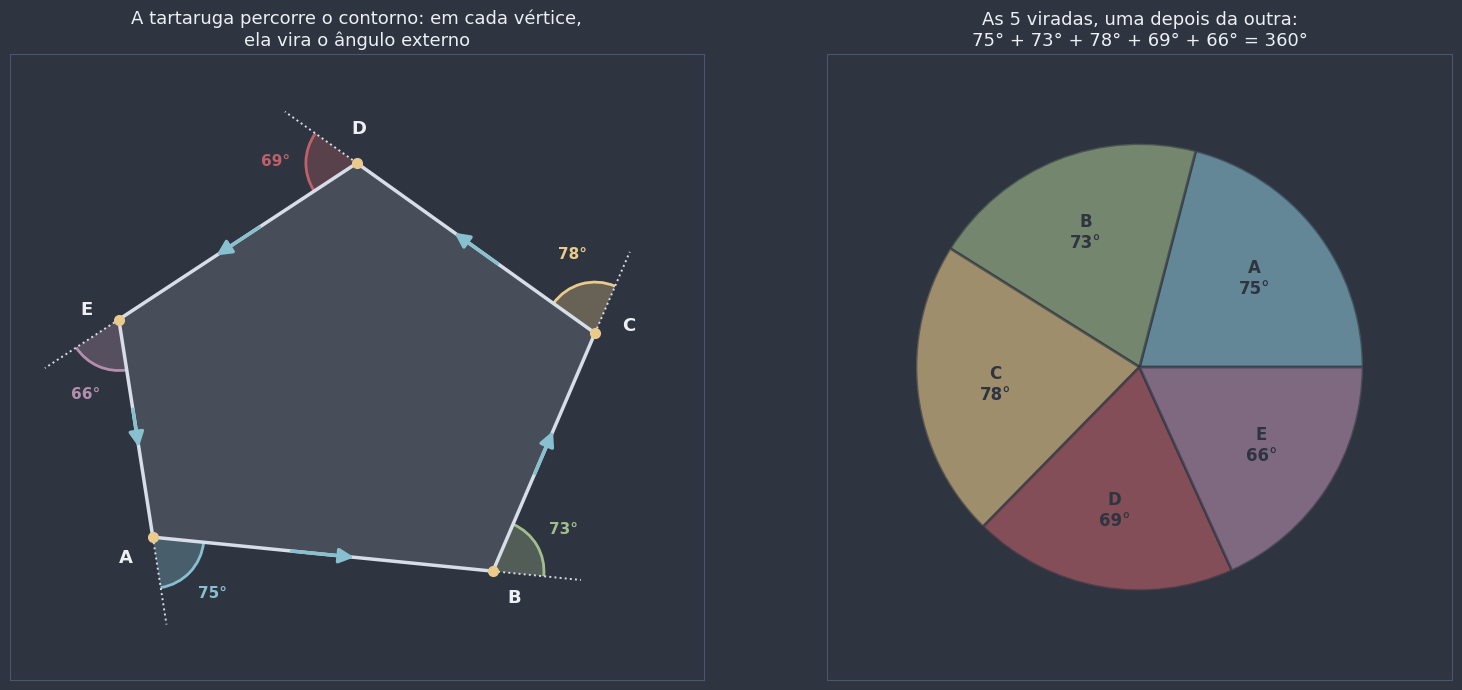

In [24]:
externos = angulos_externos(pentagono)
n = len(pentagono)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={"width_ratios": [1.3, 1]})
fig.patch.set_facecolor(NORD_FUNDO)
preparar_eixo(ax1, pentagono, margem=1.6)
desenhar_poligono(ax1, pentagono, cor=NORD_TEXTO_SEC, largura=2.5)
for k in range(n):
    P, Q = pentagono[k], pentagono[(k + 1) % n]
    ax1.annotate("", xy=P + 0.6 * (Q - P), xytext=P + 0.4 * (Q - P),
                 arrowprops={"arrowstyle": "-|>", "color": COR_PONTO, "lw": 2.5, "mutation_scale": 22})
    chegada = direcao_de(pentagono[k - 1], P)
    ax1.plot(*zip(P, P + 1.3 * direcao(chegada)), color=NORD_TEXTO_SEC, lw=1.4, linestyle=":")
    desenhar_setor(ax1, P, chegada, externos[k], raio=0.75, cor=CORES_CATEGORICAS[k], marcar_reto=False,
                   rotulo=f"{externos[k]:.0f}°", raio_rotulo=1.2, tamanho_fonte=11)
rotular_vertices(ax1, pentagono, distancia=0.5)
ax1.set_title("A tartaruga percorre o contorno: em cada vértice,\nela vira o ângulo externo", color=NORD_TEXTO,
              fontsize=13)

preparar_eixo(ax2, [(-1.3, -1.3), (1.3, 1.3)], margem=0.1)
inicio = 0.0
for k, e in enumerate(externos):
    cor = CORES_CATEGORICAS[k]
    ax2.add_patch(Wedge((0, 0), 1, inicio, inicio + e, facecolor=cor, alpha=0.6, edgecolor=NORD_FUNDO, lw=2))
    ax2.text(*(0.65 * direcao(inicio + e / 2)), f"{LETRAS[k]}\n{e:.0f}°", color=NORD_FUNDO, fontsize=12,
             fontweight="bold", ha="center", va="center")
    inicio += e
ax2.set_title(f"As 5 viradas, uma depois da outra:\n{' + '.join(f'{e:.0f}°' for e in externos)} = {sum(externos):.0f}°",
              color=NORD_TEXTO, fontsize=13)
plt.tight_layout()
plt.show()

🕹️ **Widget interativo:** a tartaruga (a seta amarela) percorre um polígono regular de `n` lados, um lado por vez, conforme você aumenta o slider `passos`. Em cada vértice por onde passou aparece a virada que ela fez (o ângulo externo), e o **relógio de viradas**, à direita, vai acumulando o quanto ela já girou. Quando `passos` chega a `n`, ela está de volta ao começo, olhando para a mesma direção: quanto marca o relógio? Mude o `n` e repita.

In [ ]:
def caminho_da_tartaruga(comandos, inicio=(0.0, 0.0), rumo: float = 0.0) -> tuple[list[np.ndarray], float]:
    """Simula a tartaruga: cada comando (avanco, virada) faz ela andar `avanco` para a frente e, em
    seguida, virar `virada` graus para a esquerda (negativo = para a direita).
    Devolve a lista dos pontos por onde ela passou e o total de graus que ela virou."""
    posicao = np.array(inicio, dtype=float)
    pontos = [posicao]
    total_virado = 0.0
    for avanco, virada in comandos:
        posicao = posicao + avanco * direcao(rumo)
        pontos.append(posicao)
        rumo += virada
        total_virado += virada
    return pontos, total_virado


def explorar_tartaruga(n: int, passos: int) -> None:
    passos = min(passos, n)
    virada = 360 / n
    pontos, _ = caminho_da_tartaruga([(1.0, virada)] * n)
    vertices = pontos[:-1]
    centro = np.mean(vertices, axis=0)
    raio = max(math.dist(centro, v) for v in vertices)
    fig, (ax, ax_relogio) = plt.subplots(1, 2, figsize=(14, 6.4), gridspec_kw={"width_ratios": [1.25, 1]})
    fig.patch.set_facecolor(NORD_FUNDO)
    preparar_eixo(ax, [centro - raio, centro + raio], margem=0.6)
    desenhar_poligono(ax, vertices, cor=NORD_LINHA, largura=1.5, estilo="--", preencher=False)
    for k in range(passos):
        P = pontos[k + 1]
        rumo_chegada = k * virada
        ax.plot(*zip(pontos[k], P), color=COR_PONTO, lw=3.5, solid_capstyle="round")
        ax.plot(*zip(P, P + 0.55 * direcao(rumo_chegada)), color=NORD_TEXTO_SEC, lw=1.2, linestyle=":")
        desenhar_setor(ax, P, rumo_chegada, virada, raio=0.4, cor=CORES_CATEGORICAS[k % 7], marcar_reto=False)
    posicao, rumo = pontos[passos], passos * virada
    ax.plot(*posicao, "o", color=COR_AVISO, markersize=11, zorder=7)
    ax.annotate("", xy=posicao + 0.45 * direcao(rumo), xytext=posicao,
                arrowprops={"arrowstyle": "-|>", "color": COR_AVISO, "lw": 3, "mutation_scale": 25}, zorder=8)
    ax.set_title(f"{nome_poligono(n)} regular: a cada vértice, a tartaruga vira 360° ÷ {n} = {virada:.4g}°",
                 color=NORD_TEXTO, fontsize=12)

    preparar_eixo(ax_relogio, [(-1.2, -1.2), (1.2, 1.2)], margem=0.05)
    ax_relogio.add_patch(Circle((0, 0), 1, fill=False, edgecolor=NORD_TEXTO_SEC, lw=1.5, linestyle="--"))
    for k in range(passos):
        ax_relogio.add_patch(Wedge((0, 0), 1, k * virada, (k + 1) * virada, facecolor=CORES_CATEGORICAS[k % 7],
                                   alpha=0.6, edgecolor=NORD_FUNDO, lw=1.5))
    ax_relogio.text(0, -1.12, f"{passos} × {virada:.4g}° = {passos * virada:.4g}°", color=NORD_TEXTO, fontsize=14,
                    fontweight="bold", ha="center", va="top")
    completou = passos == n
    ax_relogio.set_title("Relógio de viradas: " + ("UMA VOLTA COMPLETA, 360° ✓" if completou else
                                                   f"{passos} de {n} viradas"),
                         color=COR_DESTAQUE if completou else NORD_TEXTO, fontsize=13)
    plt.tight_layout()
    plt.show()


widgets.interact(
    explorar_tartaruga,
    n=widgets.IntSlider(value=5, min=3, max=20, step=1, description="n:"),
    passos=widgets.IntSlider(value=2, min=0, max=20, step=1, description="passos:"),
);

interactive(children=(IntSlider(value=5, description='n:', max=20, min=3), IntSlider(value=2, description='pas…

💡 **Dica — polígono regular:** num polígono regular, as $n$ viradas são iguais, então cada ângulo externo mede

$$a_e = \frac{360^\circ}{n}.$$

Isso dá um jeito muito rápido de descobrir o número de lados: se o ângulo externo de um polígono regular mede 30°, então $n = \frac{360^\circ}{30^\circ} = 12$, um dodecágono. E como interno e externo são suplementares, $a_i = 180^\circ - a_e$ (no hexágono regular: $180^\circ - 60^\circ = 120^\circ$, o mesmo valor da seção 4). Mais sobre isso em 📌 Polígonos Regulares e Comprimento da Circunferência.

🕵️ **Curiosidade histórica:** a ideia da tartaruga que anda e vira não é só uma imagem: ela é a base da **geometria da tartaruga**, criada no fim dos anos 1960 com a linguagem de programação **Logo**, desenvolvida por Wally Feurzeig, Cynthia Solomon e Seymour Papert para ensinar matemática e programação a crianças. Os comandos eram exatamente "avance" e "vire", e desenhar um polígono regular de $n$ lados era repetir $n$ vezes "avance $d$, vire $360/n$". O Python herdou essa ideia no módulo `turtle`, que vem instalado com a linguagem. Se você tem o Python no seu computador (no Colab ele não abre a janela de desenho), experimente:

```python
import turtle

t = turtle.Turtle()
for _ in range(6):   # um hexágono
    t.forward(100)   # avance 100 passos
    t.left(60)       # vire 360/6 = 60 graus para a esquerda
turtle.done()
```

Aqui no notebook, a função `caminho_da_tartaruga` faz a mesma coisa com o matplotlib: ela recebe a lista de comandos `(avanço, virada)` e devolve o caminho percorrido e o **total virado**. Veja os polígonos regulares desenhados só com "avance 1, vire $360/n$":

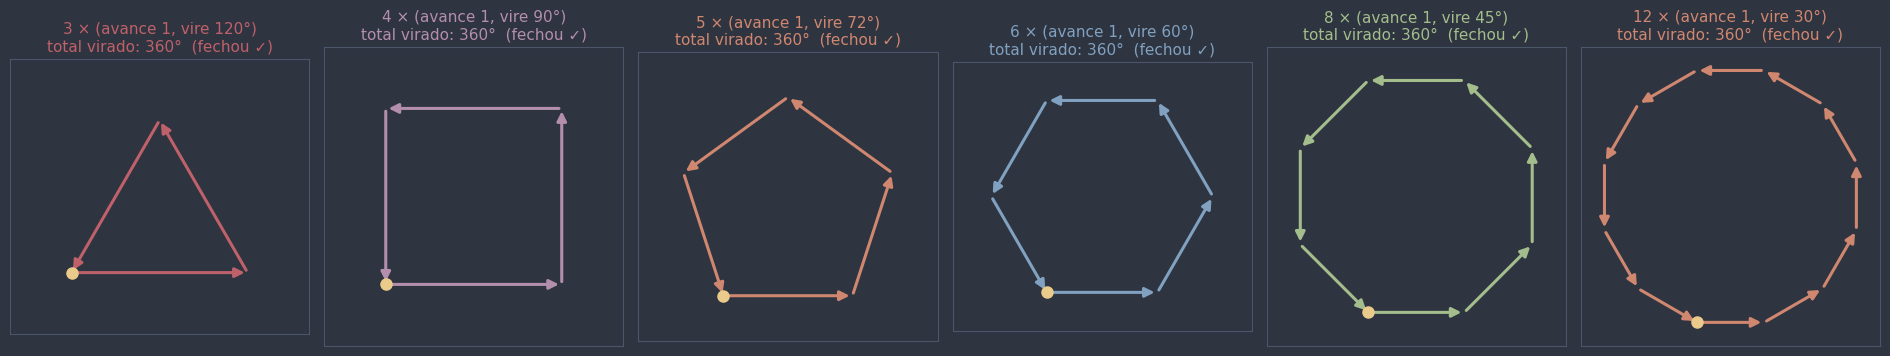

In [26]:
fig, eixos = plt.subplots(1, 6, figsize=(19, 4.2))
fig.patch.set_facecolor(NORD_FUNDO)
for ax, n in zip(eixos, [3, 4, 5, 6, 8, 12]):
    comandos = [(1.0, 360 / n)] * n
    pontos, total = caminho_da_tartaruga(comandos)
    cor = CORES_CATEGORICAS[n % 7]
    preparar_eixo(ax, pontos, margem=0.35)
    for k in range(n):
        P, Q = pontos[k], pontos[k + 1]
        ax.annotate("", xy=Q, xytext=P, arrowprops={"arrowstyle": "-|>", "color": cor, "lw": 2.2,
                                                     "mutation_scale": 14})
    ax.plot(*pontos[0], "o", color=COR_AVISO, markersize=8, zorder=6)
    fechou = np.allclose(pontos[-1], pontos[0])
    ax.set_title(f"{n} × (avance 1, vire {360 / n:.4g}°)\ntotal virado: {total:.0f}°  "
                 f"{'(fechou ✓)' if fechou else ''}", color=cor, fontsize=11)
plt.tight_layout()
plt.show()

🎯 **Aplicação prática — robótica e navegação:** um robô aspirador que contorna os móveis de uma sala, ou um drone que patrulha o perímetro de um terreno, faz exatamente o que a tartaruga faz: anda em linha reta e vira. Os sensores de rotação (giroscópios) vão **somando as viradas**; quando o total chega a 360°, o robô sabe que deu a volta completa no obstáculo e está de novo apontando na direção inicial. É a soma dos ângulos externos trabalhando como um "contador de voltas".

Com isso, a tabela do gancho está completa:

| | triângulo ($n = 3$) | quadrilátero ($n = 4$) | polígono de $n$ lados |
|---|---|---|---|
| número de diagonais | 0 | 2 | $\dfrac{n(n-3)}{2}$ |
| soma dos ângulos internos | 180° | 360° | $(n - 2) \cdot 180^\circ$ |
| soma dos ângulos externos | 360° | 360° | **360°**, sempre |

📖 **Leitura complementar:** [Gráficos tartaruga](https://pt.wikipedia.org/wiki/Gr%C3%A1ficos_tartaruga)

**Pergunta de checagem:** cada ângulo externo de um polígono regular mede 24°. Quantos lados ele tem?

**Pergunta de checagem:** existe polígono regular cujo ângulo externo meça 50°? E 45°? Justifique.

## Resumo — cheat sheet

| Conceito | Ideia-chave |
|---|---|
| **Polígono (simples)** | linha poligonal **fechada** e **sem cruzamentos**; $n$ lados = $n$ vértices = $n$ ângulos internos |
| **Elementos** | vértices, lados, ângulos internos, ângulos externos ($\hat{e} = 180^\circ - \hat{\imath}$), diagonais (vértices **não consecutivos**), perímetro (soma dos lados) |
| **Convexo** | o segmento entre dois pontos quaisquer fica dentro ⇔ todos os ângulos internos $< 180^\circ$ ⇔ a reta de cada lado deixa o polígono de um lado só |
| **Côncavo** | pelo menos um ângulo interno $> 180^\circ$ (uma "ponta afundada") |
| **Nomes** | 3 triângulo, 4 quadrilátero, 5 pentágono, 6 hexágono, 7 heptágono, 8 octógono, 9 eneágono, 10 decágono, 11 undecágono, 12 dodecágono, 20 icoságono |
| **Equilátero / equiângulo / regular** | lados ≡ / ângulos ≡ / **os dois** (losango: só equilátero; retângulo: só equiângulo; quadrado: regular) |

| Fórmula (polígono convexo de $n$ lados) | De onde vem |
|---|---|
| $d = \dfrac{n(n - 3)}{2}$ | de cada vértice partem $n - 3$ diagonais; $n(n - 3)$ pontas, cada diagonal contada 2 vezes |
| $S_i = (n - 2) \cdot 180^\circ$ | as $n - 3$ diagonais de um vértice dividem o polígono em $n - 2$ triângulos |
| $S_e = 360^\circ$ | $S_i + S_e = n \cdot 180^\circ$; a tartaruga dá **uma volta completa** |
| **Regular:** $a_i = \dfrac{(n - 2) \cdot 180^\circ}{n}$ e $a_e = \dfrac{360^\circ}{n}$ | ângulos iguais: divide a soma por $n$; $a_i + a_e = 180^\circ$ |

| Valores que valem decorar | $n = 3$ | $4$ | $5$ | $6$ | $8$ | $10$ | $12$ |
|---|---|---|---|---|---|---|---|
| diagonais | 0 | 2 | 5 | 9 | 20 | 35 | 54 |
| $S_i$ | 180° | 360° | 540° | 720° | 1080° | 1440° | 1800° |
| $a_i$ (regular) | 60° | 90° | 108° | 120° | 135° | 144° | 150° |
| $a_e$ (regular) | 120° | 90° | 72° | 60° | 45° | 36° | 30° |

**A ideia central:** triângulo (3) → quadrilátero (4) → polígono ($n$). A mesma técnica, **dividir em triângulos**, explica o $(n - 2)$ da soma dos ângulos internos; contar **pares não vizinhos** explica o $(n - 3)$ das diagonais; e a tartaruga que volta à direção de partida explica os 360° dos ângulos externos.

## Exercícios

**Básico**
1. Calcular o número de diagonais e a soma dos ângulos internos de alguns polígonos, e dar os seus nomes.
2. Calcular um ângulo interno e um ângulo externo de três polígonos regulares.

**Intermediário**

3. Escrever as funções das três fórmulas (e a que descobre o número de lados pelo ângulo externo) e validá-las contra valores conhecidos e contra a força bruta.
4. Descobrir o número de lados de um polígono a partir do número de diagonais, da soma dos ângulos internos ou do ângulo externo.

**Desafio**

5. Contar, por força bruta, de quantas maneiras um polígono convexo pode ser dividido em triângulos (e descobrir uma sequência famosa).
6. O pentagrama: a tartaruga que dá **duas** voltas.

Gabarito completo com resolução comentada em [`0411b_poligonos_gabarito.ipynb`](0411b_poligonos_gabarito.ipynb) — tente resolver sozinho antes de olhar.

### Básico

In [ ]:
# Exercício Básico 1:
# (a) Calcule o número de diagonais dos polígonos convexos de 5, 8, 15 e 20 lados. Guarde num
#     dicionário `diagonais_ex1` em que a chave é o número de lados e o valor é o número de diagonais:
#     {5: ..., 8: ..., 15: ..., 20: ...}.
# (b) Calcule a soma dos ângulos internos (em graus) dos polígonos convexos de 7, 9 e 12 lados e guarde
#     no dicionário `somas_ex1`, do mesmo jeito: {7: ..., 9: ..., 12: ...}.
# (c) Guarde em `nomes_ex1` a lista com os nomes dos polígonos do item (b), na ordem (7, 9 e 12 lados).
diagonais_ex1 = ...
somas_ex1 = ...
nomes_ex1 = ...

print(diagonais_ex1)
print(somas_ex1)
print(nomes_ex1)

In [ ]:
# Verificação
assert isinstance(diagonais_ex1, dict) and set(diagonais_ex1) == {5, 8, 15, 20}, (
    "Tente de novo, revise: `diagonais_ex1` deve ser um dicionário com as chaves 5, 8, 15 e 20 "
    "(seção 3 - Diagonais de um polígono)."
)
for n_ex1, d_certo in {5: 5, 8: 20, 15: 90, 20: 170}.items():
    assert diagonais_ex1[n_ex1] == d_certo, (
        f"Tente de novo, revise: com n = {n_ex1}, d = n(n − 3)/2 = {n_ex1}·{n_ex1 - 3}/2 "
        "(seção 3 - Diagonais de um polígono)."
    )
assert isinstance(somas_ex1, dict) and set(somas_ex1) == {7, 9, 12}, (
    "Tente de novo, revise: `somas_ex1` deve ser um dicionário com as chaves 7, 9 e 12 "
    "(seção 4 - Soma dos ângulos internos)."
)
for n_ex1, s_certo in {7: 900, 9: 1260, 12: 1800}.items():
    assert math.isclose(somas_ex1[n_ex1], s_certo), (
        f"Tente de novo, revise: com n = {n_ex1}, S_i = (n − 2)·180° = {n_ex1 - 2}·180° "
        "(seção 4 - Soma dos ângulos internos)."
    )
assert nomes_ex1 is not ... and [str(nome).strip().lower() for nome in nomes_ex1] == ["heptágono", "eneágono",
                                                                                       "dodecágono"], (
    "Tente de novo, revise: a tabela de nomes, ou a função nome_poligono (seção 2 - Nomenclatura e classificação)."
)
print("Certo!")

In [ ]:
# Exercício Básico 2:
# Para o hexágono regular, o octógono regular e o decágono regular, calcule a medida (em graus) de UM
# ângulo interno e de UM ângulo externo. Guarde em `angulos_ex2`, um dicionário em que a chave é o
# número de lados e o valor é a tupla (interno, externo): {6: (..., ...), 8: (..., ...), 10: (..., ...)}.
# Depois, guarde em `suplementares_ex2` True se, nos três casos, interno + externo = 180°
# (calcule com o seu dicionário, não escreva True direto!).
angulos_ex2 = ...
suplementares_ex2 = ...

print(angulos_ex2)
print(suplementares_ex2)

In [ ]:
# Verificação
assert isinstance(angulos_ex2, dict) and set(angulos_ex2) == {6, 8, 10}, (
    "Tente de novo, revise: `angulos_ex2` deve ser um dicionário com as chaves 6, 8 e 10 "
    "(seção 5 - Soma dos ângulos externos)."
)
for n_ex2, (interno_certo, externo_certo) in {6: (120, 60), 8: (135, 45), 10: (144, 36)}.items():
    interno_ex2, externo_ex2 = angulos_ex2[n_ex2]
    assert math.isclose(interno_ex2, interno_certo), (
        f"Tente de novo, revise: no regular de {n_ex2} lados, a_i = (n − 2)·180°/n "
        "(seção 4 - Soma dos ângulos internos)."
    )
    assert math.isclose(externo_ex2, externo_certo), (
        f"Tente de novo, revise: no regular de {n_ex2} lados, a_e = 360°/n (seção 5 - Soma dos ângulos externos)."
    )
assert suplementares_ex2 is True or suplementares_ex2 is np.True_, (
    "Tente de novo, revise: interno e externo são suplementares em cada vértice "
    "(seção 5 - Soma dos ângulos externos)."
)
print("Certo!")

### Intermediário

In [ ]:
# Exercício Intermediário 3: as fórmulas do notebook, com as suas próprias funções.
# Complete as quatro funções abaixo (sem chamar num_diagonais, soma_angulos_internos nem
# soma_angulos_externos, que já estão prontas no notebook):
#   - num_diagonais_ex3(n): o número de diagonais de um polígono convexo de n lados (um int);
#   - soma_internos_ex3(n): a soma dos ângulos internos, em graus;
#   - soma_externos_ex3(n): a soma dos ângulos externos, em graus;
#   - lados_pelo_externo_ex3(angulo): o número de lados (um int) do polígono REGULAR cujo ângulo
#     externo mede `angulo` graus, ou None se não existir polígono regular com esse ângulo externo
#     (por exemplo, 50°: 360/50 não é um número inteiro). Cuidado com as contas com float: 360 / 7.2
#     pode não dar exatamente 50.0 (use round e math.isclose). E lembre que n ≥ 3.
# A verificação compara com triângulo, quadrilátero e hexágono, e com a contagem por força bruta
# (contar_diagonais_forca_bruta) de n = 3 até n = 30.


def num_diagonais_ex3(n: int) -> int:
    ...


def soma_internos_ex3(n: int) -> float:
    ...


def soma_externos_ex3(n: int) -> float:
    ...


def lados_pelo_externo_ex3(angulo: float) -> int | None:
    ...


print(num_diagonais_ex3(6), soma_internos_ex3(6), soma_externos_ex3(6), lados_pelo_externo_ex3(60))

In [ ]:
# Verificação
for n_ex3, d_ex3, si_ex3 in [(3, 0, 180), (4, 2, 360), (6, 9, 720)]:
    assert num_diagonais_ex3(n_ex3) == d_ex3, (
        f"Tente de novo, revise: o {nome_poligono(n_ex3)} tem {d_ex3} diagonais; d = n(n − 3)/2 "
        "(seção 3 - Diagonais de um polígono)."
    )
    assert soma_internos_ex3(n_ex3) is not None and math.isclose(soma_internos_ex3(n_ex3), si_ex3), (
        f"Tente de novo, revise: no {nome_poligono(n_ex3)}, S_i = {si_ex3}°; S_i = (n − 2)·180° "
        "(seção 4 - Soma dos ângulos internos)."
    )
for n_ex3 in range(3, 31):
    assert num_diagonais_ex3(n_ex3) == contar_diagonais_forca_bruta(poligono_regular(n_ex3)), (
        f"Tente de novo, revise: com n = {n_ex3}, a sua fórmula não bate com a força bruta "
        "(seção 3 - Diagonais de um polígono)."
    )
    assert isinstance(num_diagonais_ex3(n_ex3), int), (
        "Tente de novo, revise: o número de diagonais é um inteiro; use a divisão inteira // "
        "(seção 3 - Diagonais de um polígono)."
    )
    assert soma_externos_ex3(n_ex3) is not None and math.isclose(soma_externos_ex3(n_ex3), 360), (
        "Tente de novo, revise: a soma dos ângulos externos não depende de n (seção 5 - Soma dos ângulos externos)."
    )
for angulo_ex3, lados_certos in [(120, 3), (90, 4), (60, 6), (30, 12), (18, 20), (24, 15), (7.2, 50), (1, 360)]:
    assert lados_pelo_externo_ex3(angulo_ex3) == lados_certos, (
        f"Tente de novo, revise: ângulo externo de {angulo_ex3}° dá n = 360/{angulo_ex3} = {lados_certos} "
        "(seção 5 - Soma dos ângulos externos)."
    )
for angulo_ex3 in [50, 25, 7, 150, 180, 200]:
    assert lados_pelo_externo_ex3(angulo_ex3) is None, (
        f"Tente de novo, revise: não existe polígono regular com ângulo externo de {angulo_ex3}° "
        "(360 dividido por ele não é um inteiro maior ou igual a 3) (seção 5 - Soma dos ângulos externos)."
    )
print("Certo!")

In [ ]:
# Exercício Intermediário 4: descobrindo o número de lados.
# Descubra o número de lados de um polígono convexo sabendo que:
#   (a) ele tem 35 diagonais. Guarde n em `n_a_ex4`.
#       Por álgebra: n(n − 3)/2 = 35  ->  n² − 3n − 70 = 0, uma equação do 2º grau. Guarde as DUAS
#       raízes dessa equação, em ordem crescente, na lista `raizes_ex4` (use a fórmula de Bhaskara com
#       math.sqrt) e pense: por que só uma delas serve?
#   (b) a soma dos seus ângulos internos é 1980°. Guarde n em `n_b_ex4`.
#   (c) ele é regular e o seu ângulo externo mede 18°. Guarde n em `n_c_ex4`.
# Você pode resolver por álgebra ou por código, varrendo os valores de n (por exemplo, de 3 a 100)
# até encontrar o que satisfaz a condição.
n_a_ex4 = ...
raizes_ex4 = ...
n_b_ex4 = ...
n_c_ex4 = ...

print(n_a_ex4, raizes_ex4, n_b_ex4, n_c_ex4)

In [ ]:
# Verificação
assert n_a_ex4 == 10, (
    "Tente de novo, revise: procure n com n(n − 3)/2 = 35 (seção 3 - Diagonais de um polígono)."
)
assert raizes_ex4 is not ... and len(raizes_ex4) == 2 and np.allclose(sorted(raizes_ex4), [-7, 10]), (
    "Tente de novo, revise: em n² − 3n − 70 = 0, Δ = 9 + 280 = 289 e n = (3 ± 17)/2; o número de lados "
    "não pode ser negativo (seção 3 - Diagonais de um polígono)."
)
assert n_b_ex4 == 13, (
    "Tente de novo, revise: (n − 2)·180 = 1980  ->  n − 2 = 11 (seção 4 - Soma dos ângulos internos)."
)
assert n_c_ex4 == 20, (
    "Tente de novo, revise: no regular, a_e = 360°/n  ->  n = 360/18 (seção 5 - Soma dos ângulos externos)."
)
print("Certo!")

### Desafio

In [ ]:
# Exercício Desafio 5: de quantas maneiras dá para triangular um polígono convexo?
# Na seção 4, dividimos o polígono em triângulos com o "leque" de diagonais saindo de um vértice. Mas
# há outras maneiras: o quadrilátero pode ser dividido pela diagonal AC OU pela diagonal BD (2 maneiras).
# Uma TRIANGULAÇÃO de um polígono convexo de n lados é uma escolha de diagonais que NÃO se cruzam e
# que dividem o polígono em triângulos; toda triangulação usa exatamente n − 3 diagonais (por quê?
# releia a seção 4: n − 2 triângulos exigem n − 3 cortes).
# (a) Para cada n de 3 a 8, conte por força bruta quantas triangulações existem:
#       - gere os vértices com poligono_regular(n) e a lista de diagonais com diagonais_do_poligono;
#       - percorra todas as escolhas de n − 3 diagonais (combinations(lista_de_diagonais, n − 3));
#       - conte as escolhas em que NENHUM par de diagonais se cruza (use segmentos_se_cruzam; diagonais
#         que só compartilham um vértice NÃO se cruzam, e a função já trata isso).
#     Guarde a lista das 6 contagens (n = 3, 4, ..., 8) em `triangulacoes_ex5`.
#     (Para n = 3, combinations(lista, 0) tem uma única escolha: a escolha vazia, o próprio triângulo.)
# (b) Olhe a sequência. Guarde em `razao_ex5` a lista das razões entre cada termo e o anterior
#     (triangulacoes_ex5[k] / triangulacoes_ex5[k − 1], para k = 1, ..., 5). Ela é constante?
triangulacoes_ex5 = ...
razao_ex5 = ...

print(triangulacoes_ex5)
print(razao_ex5)

In [ ]:
# Verificação
assert triangulacoes_ex5 is not ... and len(triangulacoes_ex5) == 6, (
    "Tente de novo, revise: são 6 contagens, uma para cada n de 3 a 8 (seção 4 - Soma dos ângulos internos)."
)
assert triangulacoes_ex5[0] == 1 and triangulacoes_ex5[1] == 2, (
    "Tente de novo, revise: o triângulo já é triangulado (1 maneira) e o quadrilátero tem 2 (AC ou BD); "
    "confira o laço com combinations(diagonais, n − 3) (seção 3 - Diagonais de um polígono)."
)
assert list(triangulacoes_ex5) == [1, 2, 5, 14, 42, 132], (
    "Tente de novo, revise: descarte as escolhas em que algum par de diagonais se cruza, testando todos os "
    "pares com combinations(escolha, 2) e segmentos_se_cruzam (seção 3 - Diagonais de um polígono)."
)
assert razao_ex5 is not ... and len(razao_ex5) == 5 and np.allclose(razao_ex5, [2, 2.5, 2.8, 3, 132 / 42]), (
    "Tente de novo, revise: razao_ex5[k − 1] = triangulacoes_ex5[k] / triangulacoes_ex5[k − 1] "
    "(seção 4 - Soma dos ângulos internos)."
)
print("Certo!")

In [ ]:
# Exercício Desafio 6: o pentagrama e a tartaruga que dá DUAS voltas.
# A estrela de cinco pontas (o pentagrama) pode ser desenhada pela tartaruga com 5 comandos iguais:
# "avance 1 e vire X graus para a esquerda". Diferente do pentágono, a tartaruga NÃO fecha a figura
# depois de uma volta: o pentagrama só se fecha depois de ela dar DUAS voltas completas.
# (a) Descubra X, sabendo que as 5 viradas iguais somam duas voltas completas. Guarde em `virada_ex6`.
# (b) Monte a lista `comandos_ex6` com os 5 comandos (avanço, virada) e use caminho_da_tartaruga para
#     simular o desenho. Guarde a lista de pontos em `pontos_ex6` e o total virado em `total_virado_ex6`.
#     (Confira: o último ponto deve coincidir com o primeiro.)
# (c) Em cada ponta da estrela, o ângulo da ponta e a virada da tartaruga são suplementares (como o
#     ângulo interno e o externo de um polígono). Guarde a medida de cada ponta em `ponta_ex6` e a soma
#     das 5 pontas em `soma_pontas_ex6`.
# (d) O pentagrama é um polígono simples? Guarde a resposta (True ou False) em `simples_ex6`, usando a
#     função eh_simples com os 5 vértices (pontos_ex6 sem o último ponto, que repete o primeiro).
virada_ex6 = ...
comandos_ex6 = ...
pontos_ex6, total_virado_ex6 = ..., ...
ponta_ex6 = ...
soma_pontas_ex6 = ...
simples_ex6 = ...

print(virada_ex6, total_virado_ex6, ponta_ex6, soma_pontas_ex6, simples_ex6)

In [ ]:
# Verificação
assert virada_ex6 is not ... and math.isclose(virada_ex6, 144), (
    "Tente de novo, revise: 5 viradas iguais somando 2 voltas: 5·X = 2·360° (seção 5 - Soma dos ângulos externos)."
)
assert comandos_ex6 is not ... and len(comandos_ex6) == 5, (
    "Tente de novo, revise: são 5 comandos (avanço, virada), um por ponta (seção 5 - Soma dos ângulos externos)."
)
assert pontos_ex6 is not ... and np.allclose(pontos_ex6[-1], pontos_ex6[0]), (
    "Tente de novo, revise: pontos_ex6, total_virado_ex6 = caminho_da_tartaruga(comandos_ex6); a estrela "
    "precisa fechar (seção 5 - Soma dos ângulos externos)."
)
assert total_virado_ex6 is not ... and math.isclose(total_virado_ex6, 720), (
    "Tente de novo, revise: o total virado é a soma das viradas, duas voltas (seção 5 - Soma dos ângulos externos)."
)
assert ponta_ex6 is not ... and math.isclose(ponta_ex6, 36), (
    "Tente de novo, revise: ponta + virada = 180° (seção 5 - Soma dos ângulos externos)."
)
assert soma_pontas_ex6 is not ... and math.isclose(soma_pontas_ex6, 180), (
    "Tente de novo, revise: some as 5 pontas iguais (seção 5 - Soma dos ângulos externos)."
)
assert simples_ex6 is False or simples_ex6 is np.False_, (
    "Tente de novo, revise: eh_simples(pontos_ex6[:-1]); no pentagrama, lados não vizinhos se cruzam "
    "(seção 1 - O que é um polígono: definição e elementos)."
)
print("Certo!")

## Conexões

**Isso depende de:**
- [`0403a_angulos.ipynb`](0403a_angulos.ipynb) (ângulos adjacentes e suplementares, que somam os pedaços de ângulo da triangulação e ligam o ângulo interno ao externo)
- [`0404a_triangulos_conceito_elementos_e_classificacao.ipynb`](0404a_triangulos_conceito_elementos_e_classificacao.ipynb) (a soma de 180° dos ângulos internos do triângulo, o ângulo externo e as malhas de triângulos)
- [`0406a_paralelismo.ipynb`](0406a_paralelismo.ipynb) (a demonstração formal dos 180°, base de toda a seção 4)
- [`0408a_quadrilateros_definicao_elementos_e_trapezios.ipynb`](0408a_quadrilateros_definicao_elementos_e_trapezios.ipynb) (a soma de 360° pela divisão em dois triângulos, as duas diagonais, a distinção convexo × côncavo e as funções `orientacao` e `angulos_internos`)
- [`0409a_paralelogramos_e_casos_particulares.ipynb`](0409a_paralelogramos_e_casos_particulares.ipynb) (losango, retângulo e quadrado como exemplos e contraexemplos de polígono regular)

**Isso será usado em:**
- [`0412a_circunferencia_e_circulo.ipynb`](0412a_circunferencia_e_circulo.ipynb) (polígonos inscritos e circunscritos, e quadriláteros inscritíveis e circunscritíveis)
- 📌 Polígonos Regulares e Comprimento da Circunferência (centro, raio e apótema dos polígonos regulares, as fórmulas $a_i$ e $a_e$ desenvolvidas, e a aproximação da circunferência por polígonos de muitos lados)
- 📌 Equivalência Plana (decomposição de polígonos em triângulos para comparar áreas)
- 📌 Áreas de Superfícies Planas (a área de um polígono qualquer pela soma das áreas dos triângulos de uma triangulação)
- 📌 Análise Combinatória (módulo 08: a contagem de diagonais como $C(n, 2) - n$ e os números de Catalan do Desafio 5)